In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import spacepy
import os
from uncertainties import ufloat, unumpy
import datetime as dt
import copy
import seaborn as sns
import geopandas as gpd

%load_ext autoreload
%autoreload 2

import spectra_running_tools as SRT

import sketch


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
def save_figure_for_paper(file_name:str):

    path_to_paper_folder = "../../../../../windowsDesktop/HEPI background paper files/"

    plt.savefig(path_to_paper_folder + file_name + ".png", bbox_inches="tight",dpi=500)
    plt.savefig(path_to_paper_folder + file_name + ".eps", bbox_inches="tight",dpi=500)

In [18]:
SRT.default_shielding_geometry.aluminium_thickness_in_mm

2.0

In [19]:
SRT.default_shielding_geometry.tantalum_thickness_in_mm

0.5

In [20]:
from tqdm import tqdm

In [21]:
def fill_between_errorbar(x_vals,y_vals,y_err,**kwargs):

    plt.plot(x_vals,
            y_vals,
            marker="o",
            ms=3,
            **kwargs)
    plt.fill_between(x_vals,
                np.array(y_vals) - np.array(y_err),
                np.array(y_vals) + np.array(y_err),
                color=plt.gca().lines[-1].get_color(),
                alpha=0.4)

In [22]:
index_for_horns_max = 839
index_for_SAA_max = 826
index_for_polar = 847

In [23]:
spacecraft_coords_DF = pd.read_csv("IRENE8_450_circ_orbit_coords.txt",skiprows=73,header=None,skipfooter=1)
spacecraft_coords_DF.columns = ['ModifiedJulianDay',
'Altitude_km',
'Latitude_deg',
'Longitude_deg',
'LocalTime_hrs',
'PitchAngle_deg']
spacecraft_coords_DF

/tmp/ipykernel_147622/1845830959.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  spacecraft_coords_DF = pd.read_csv("IRENE8_450_circ_orbit_coords.txt",skiprows=73,header=None,skipfooter=1)


,ModifiedJulianDay,Altitude_km,Latitude_deg,Longitude_deg,LocalTime_hrs,PitchAngle_deg
0,18628.000000,1192.835,0.000000,354.938757,23.662584,90.0
1,18628.000694,1192.891,3.313331,354.688073,23.662538,90.0
2,18628.001389,1193.060,6.626412,354.437390,23.662493,90.0
3,18628.002083,1193.338,9.939000,354.186707,23.662447,90.0
4,18628.002778,1193.722,13.250860,353.936025,23.662402,90.0
...,...,...,...,...,...,...
1088,18628.755556,1193.970,-13.371240,82.192904,23.612860,90.0
1089,18628.756250,1193.583,-10.059640,81.942378,23.612825,90.0
1090,18628.756944,1193.301,-6.747288,81.691850,23.612790,90.0
1091,18628.757639,1193.129,-3.434439,81.441319,23.612755,90.0


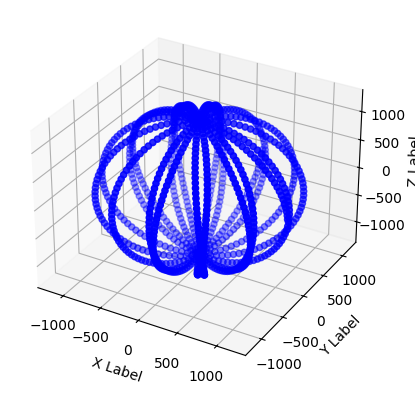

In [24]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# get the data from the dataframe
index = spacecraft_coords_DF.index
ModifiedJulianDay = spacecraft_coords_DF['ModifiedJulianDay']
Altitude_km = spacecraft_coords_DF['Altitude_km']
Latitude_deg = spacecraft_coords_DF['Latitude_deg']
Longitude_deg = spacecraft_coords_DF['Longitude_deg']
LocalTime_hrs = spacecraft_coords_DF['LocalTime_hrs']
PitchAngle_deg = spacecraft_coords_DF['PitchAngle_deg']

# convert coordinates to Cartesian 
x = Altitude_km * np.cos(np.radians(Latitude_deg)) * np.cos(np.radians(Longitude_deg)) 
y = Altitude_km * np.cos(np.radians(Latitude_deg)) * np.sin(np.radians(Longitude_deg)) 
z = Altitude_km * np.sin(np.radians(Latitude_deg)) 

# plot the trajectory in 3D 
fig = plt.figure() 
ax = fig.add_subplot(111, projection='3d') 
ax.scatter(x, y, z, c='b', marker='o') 
ax.set_xlabel('X Label') 
ax.set_ylabel('Y Label') 
ax.set_zlabel('Z Label') 
plt.show() 

In [25]:
IRENE8_450_electrons = pd.read_csv("IRENE8_450_circ_orbit_electrons.txt",skiprows=76,header=None,skipfooter=1)
IRENE8_450_electrons.columns = [
    "B Gauss",
    "L !8R!3!dE!n",
    0.04,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    1,
    1.25,
    1.5,
    1.75,
    2,
    2.25,
    2.5,
    2.75,
    3,
    3.25,
    3.5,
    3.75,
    4,
    4.25,
    4.5,
    4.75,
    5,
    5.5,
    6,
    6.5,
    7
]
IRENE8_450_electrons["B Gauss"] = spacecraft_coords_DF["Latitude_deg"]
IRENE8_450_electrons.rename(columns={"B Gauss":"Latitude_deg"},inplace=True)

IRENE8_450_electrons["L !8R!3!dE!n"] = spacecraft_coords_DF["Longitude_deg"]
IRENE8_450_electrons.rename(columns={"L !8R!3!dE!n":"Longitude_deg"},inplace=True)

IRENE8_450_electrons

/tmp/ipykernel_147622/3684036918.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  IRENE8_450_electrons = pd.read_csv("IRENE8_450_circ_orbit_electrons.txt",skiprows=76,header=None,skipfooter=1)


,Latitude_deg,Longitude_deg,0.04,0.1,0.2,0.3,0.4,0.5,0.6,0.7,...,3.75,4,4.25,4.5,4.75,5,5.5,6,6.5,7
0,0.000000,354.938757,1537300.0,1209300.0,750380.0,339930.0,112420.0,37182.0,19539.0,10268.0,...,1.6375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.313331,354.688073,729880.0,574970.0,363090.0,168080.0,57040.0,19357.0,10406.0,5594.3,...,1.5384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6.626412,354.437390,387980.0,307940.0,198260.0,94564.0,33416.0,11808.0,6514.8,3594.5,...,1.9403,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9.939000,354.186707,287760.0,228280.0,146830.0,69917.0,24649.0,8689.6,4788.0,2638.2,...,1.4023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,13.250860,353.936025,201860.0,159250.0,98662.0,45200.0,15312.0,5187.2,2785.8,1496.1,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1088,-13.371240,82.192904,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1089,-10.059640,81.942378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1090,-6.747288,81.691850,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1091,-3.434439,81.441319,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
IRENE8_450_protons = pd.read_csv("IRENE8_450_circ_orbit_protons.txt",skiprows=74,header=None,skipfooter=1)
IRENE8_450_protons.columns = [
    "B Gauss",
    "L !8R!3!dE!n",
    0.1, 
    0.15, 
    0.2, 
    0.3, 
    0.4, 
    0.5, 
    0.6, 
    0.7, 
    1, 
    1.5, 
    2, 
    3, 
    4, 
    5, 
    6, 
    7, 
    10, 
    15, 
    20, 
    30, 
    40, 
    50, 
    60, 
    70, 
    100, 
    150, 
    200, 
    300, 
    400
]
IRENE8_450_protons["B Gauss"] = spacecraft_coords_DF["Latitude_deg"]
IRENE8_450_protons.rename(columns={"B Gauss":"Latitude_deg"},inplace=True)

IRENE8_450_protons["L !8R!3!dE!n"] = spacecraft_coords_DF["Longitude_deg"]
IRENE8_450_protons.rename(columns={"L !8R!3!dE!n":"Longitude_deg"},inplace=True)

cols_to_use = [
    "Latitude_deg",
    "Longitude_deg",
    100,
    150, 
    200, 
    300, 
    400
]

IRENE8_450_protons_original = IRENE8_450_protons.copy()
IRENE8_450_protons = IRENE8_450_protons[cols_to_use]

/tmp/ipykernel_147622/3175779400.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  IRENE8_450_protons = pd.read_csv("IRENE8_450_circ_orbit_protons.txt",skiprows=74,header=None,skipfooter=1)


In [27]:
def convert_integral_values_to_differential(integral_DF):

    differential_DF_coords = integral_DF.iloc[:,:2]

    differential_DF_energy_vals = (integral_DF.iloc[:,2:-1].columns +integral_DF.iloc[:,3:].columns)/2
    differential_DF_values = -1 * integral_DF.iloc[:,2:].diff(axis=1).iloc[:,1:] / np.diff(integral_DF.iloc[:,2:].columns)
    differential_DF_values.columns = differential_DF_energy_vals

    return pd.concat([differential_DF_coords,differential_DF_values],axis=1)

In [28]:
IRENE8_450_electrons_differential = convert_integral_values_to_differential(IRENE8_450_electrons)
IRENE8_450_protons_differential = convert_integral_values_to_differential(IRENE8_450_protons)
IRENE8_450_protons_original_differential = convert_integral_values_to_differential(IRENE8_450_protons_original)

In [29]:
IRENE8_450_electrons_differential_shortened = IRENE8_450_electrons_differential.drop(columns=IRENE8_450_electrons_differential.columns[2:11])

In [30]:
IRENE8_450_electrons_differential_shortened

,Latitude_deg,Longitude_deg,1.125,1.375,1.625,1.875,2.125,2.375,2.625,2.875,...,3.625,3.875,4.125,4.375,4.625,4.875,5.25,5.75,6.25,6.75
0,0.000000,354.938757,5039.2,2607.72,922.28,618.24,504.52,302.04,199.78,111.164,...,18.7532,6.55,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1,3.313331,354.688073,2716.08,1416.32,498.24,337.44,286.28,170.52,113.232,62.176,...,11.3468,6.1536,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2,6.626412,354.437390,1774.0,945.88,337.76,232.16,201.908,122.04,82.488,45.996,...,7.4096,7.7612,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
3,9.939000,354.186707,1300.24,692.28,246.88,169.56,147.344,88.964,60.068,33.452,...,5.3692,5.6092,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
4,13.250860,353.936025,725.48,378.56,133.744,90.44,76.012,45.424,30.2536,16.6852,...,4.7284,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1088,-13.371240,82.192904,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1089,-10.059640,81.942378,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1090,-6.747288,81.691850,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
1091,-3.434439,81.441319,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [31]:
IRENE8_450_protons_differential

,Latitude_deg,Longitude_deg,125.0,175.0,250.0,350.0
0,0.000000,354.938757,9.816,6.6716,4.0078,1.7372
1,3.313331,354.688073,9.078,6.3254,3.9933,1.7975
2,6.626412,354.437390,8.1354,5.7348,3.7211,1.7
3,9.939000,354.186707,6.2192,4.38,2.8863,1.2899
4,13.250860,353.936025,4.234,2.9386,1.9272,0.81285
...,...,...,...,...,...,...
1088,-13.371240,82.192904,-0.0,-0.0,-0.0,-0.0
1089,-10.059640,81.942378,-0.0,-0.0,-0.0,-0.0
1090,-6.747288,81.691850,-0.0,-0.0,-0.0,-0.0
1091,-3.434439,81.441319,-0.0,-0.0,-0.0,-0.0


## Defining running across orbit

In [32]:
def get_photon_inducing_event_count_per_second(output_run, threshold_photon_value=10.0):
    try:
        return output_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=threshold_photon_value)
    except AttributeError:
        return output_run

In [33]:
def get_single_rad_photon_inducing_event_count_per_second(output_run, threshold_photon_value=10.0):
    try:
        return output_run.outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=threshold_photon_value)
    except AttributeError:
        return output_run

In [34]:
class orbital_run():

    def __init__(self, 
                 DF_of_coordinates_and_spectra:pd.DataFrame, 
                 particle_species:str, 
                 shielding_geometry=SRT.default_shielding_geometry,
                 label=None,
                 label_for_run=None,
                 threshold_photon_value=10.0,
                 number_of_particles_to_simulate=100_000,
                 ignore_coincidence_horns_regions=True,
                 **kwargs):

        self.run_dict = {}

        self.label = label

        self.ignore_coincidence_horns_regions = ignore_coincidence_horns_regions

        self.DF_of_coordinates_and_spectra = DF_of_coordinates_and_spectra

        for index, spectrum_row in tqdm(DF_of_coordinates_and_spectra.iterrows()):

            self.run_dict[index] = self.run_Cherenkov_simulation_across_row(particle_species, shielding_geometry, label_for_run, number_of_particles_to_simulate, spectrum_row, **kwargs)

        self.run_dict_event_counts = pd.Series(self.run_dict).apply(lambda x:get_photon_inducing_event_count_per_second(x,
                                                                                                                        threshold_photon_value=threshold_photon_value))

        horns_region_lower_limit = -50.0
        horns_region_upper_limit = 45.0
        if self.ignore_coincidence_horns_regions is True:
            for index, spectrum_row in tqdm(DF_of_coordinates_and_spectra.iterrows()):
                if not ((spectrum_row["Latitude_deg"] <=horns_region_upper_limit) & (spectrum_row["Latitude_deg"] >=horns_region_lower_limit)):
                    self.run_dict_event_counts[index] = ufloat(0.0,0.0)

        self.single_rad_run_dict_event_counts = pd.Series(self.run_dict).apply(lambda x:get_single_rad_photon_inducing_event_count_per_second(x,
                                                                                                                        threshold_photon_value=threshold_photon_value))

    def run_Cherenkov_simulation_across_row(self, particle_species, shielding_geometry, label_for_run, number_of_particles_to_simulate, spectrum_row, **kwargs):
        
        file_path_to_use = f"file_path_for_spectrum_row.csv"

        spectrum_row[2:].to_csv(file_path_to_use,header=None,sep=" ")

        max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)

        if max_particles_per_s > 0.0:

            row_as_a_spectrum = SRT.particle_spectrum(particle_species=SRT.particle(particle_species),
                                                        spectrum_file_path=file_path_to_use,
                                                        incoming_particles_per_s_per_cm2=max_particles_per_s)
                                                        
            Cherenkov_run_for_row = SRT.wrapper_gras_Cherenkov_runner_from_objects(row_as_a_spectrum,
            #Cherenkov_run_for_row = SRT.gras_Cherenkov_runner_from_objects(row_as_a_spectrum,
                                                shielding_geometry,
                                                #SRT.no_shielding_geometry,
                                                Cherenkov_run_label = label_for_run,
                                                number_of_particles=number_of_particles_to_simulate,
                                                number_of_radiators=2,
                                                **kwargs);

        else:
            Cherenkov_run_for_row = ufloat(0.0,0.0)

        os.remove(file_path_to_use)
        return Cherenkov_run_for_row

    def plot_run_dict(self, xvalues_to_use = None, error_bar_function=plt.errorbar):

        if xvalues_to_use is None:
            xvalues_to_use = self.run_dict_event_counts.index
        elif isinstance(xvalues_to_use,str):
            if xvalues_to_use == "latitudes":
                xvalues_to_use = self.DF_of_coordinates_and_spectra["Latitude_deg"]

        error_bar_function(xvalues_to_use,
                self.run_dict_event_counts.apply(lambda x:x.n),
                self.run_dict_event_counts.apply(lambda x:x.std_dev),
                label=self.label)
        plt.yscale("log")
        plt.grid(True)
        plt.ylabel("cts / second")
        plt.xlabel("Latitude (degrees)")

    def plot_single_rad_run_dict(self, xvalues_to_use = None, error_bar_function=plt.errorbar):

        if xvalues_to_use is None:
            xvalues_to_use = self.single_rad_run_dict_event_counts.index
        elif isinstance(xvalues_to_use,str):
            if xvalues_to_use == "latitudes":
                xvalues_to_use = self.DF_of_coordinates_and_spectra["Latitude_deg"]

        error_bar_function(xvalues_to_use,
                self.single_rad_run_dict_event_counts.apply(lambda x:x.n),
                self.single_rad_run_dict_event_counts.apply(lambda x:x.std_dev),
                label=self.label)
        plt.yscale("log")
        plt.grid(True)
        plt.ylabel("cts / second")
        plt.xlabel("Latitude (degrees)")

    def __add__(self, right):

        output_orbital_run = copy.deepcopy(self)

        output_orbital_run.run_dict = {0:self.run_dict, 1:right.run_dict}

        output_orbital_run.run_dict_event_counts = self.run_dict_event_counts + right.run_dict_event_counts
        output_orbital_run.label = self.label + " plus " + right.label

        return output_orbital_run

    def print_count_rates_info(self):

        print(f"polar region count rate: {self.run_dict_event_counts[index_for_polar]} cts/s".replace("+/-","±"))
        print(f"horns region count rate: {self.run_dict_event_counts[index_for_horns_max]} cts/s".replace("+/-","±"))
        print(f"SAA region count rate: {self.run_dict_event_counts[index_for_SAA_max]} cts/s".replace("+/-","±"))

In [35]:
IRENE8_450_electrons_differential_shortened_single_orbit = IRENE8_450_electrons_differential_shortened.iloc[790:850].sample(60,random_state=1).sort_index()


In [36]:
IRENE8_450_electrons_orbital_run = orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit, 
    number_of_particles_to_simulate=1_000_000, 
    particle_species="e-",
    label="AE8 electrons",
    threshold_photon_value=20.0,
    ignore_coincidence_horns_regions=False)

0it [00:00, ?it/s]

/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/home/xisacross/programming/HEPI/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values,

In [37]:
IRENE8_450_electrons_orbital_run.run_dict[800].outputted_tuple.number_of_events_simulated

1000000

In [38]:
IRENE8_450_electrons_orbital_run.run_dict_event_counts

790              0.0+/-0
791              0.0+/-0
792              0.0+/-0
793              0.0+/-0
794              0.0+/-0
795              0.0+/-0
796              0.0+/-0
797              0.0+/-0
798              0.0+/-0
799        0.000+/-0.011
800            0.0+/-0.5
801            0.0+/-2.0
802                0+/-4
803            0.0+/-3.0
804          0.00+/-0.33
805        0.000+/-0.004
806    0.00000+/-0.00024
807      0.0000+/-0.0015
808        0.000+/-0.005
809        0.000+/-0.030
810          0.00+/-0.09
811          0.00+/-0.27
812          0.00+/-0.30
813          0.00+/-0.16
814          0.00+/-0.10
815          0.00+/-0.08
816          0.00+/-0.10
817          0.00+/-0.14
818          0.00+/-0.17
819          0.00+/-0.23
820            0.0+/-0.4
821            0.0+/-0.7
822            0.0+/-0.9
823            0.0+/-2.3
824                0+/-4
825                0+/-7
826                0+/-8
827                0+/-6
828            0.0+/-3.4
829            0.0+/-1.9


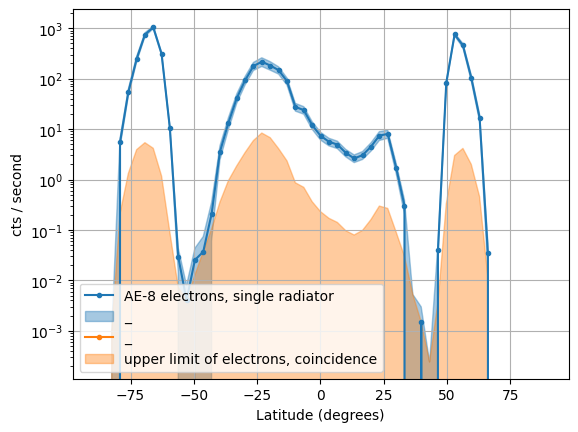

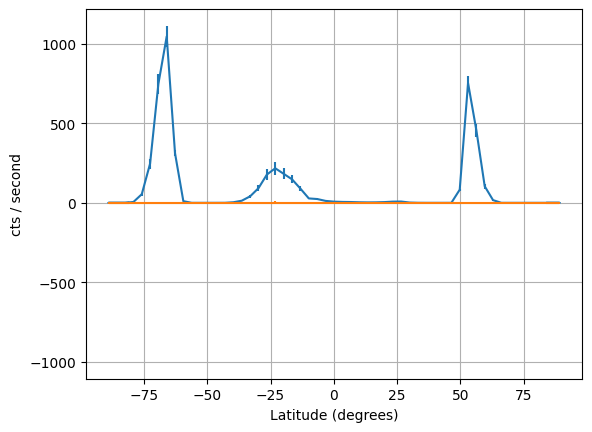

In [39]:
IRENE8_450_electrons_orbital_run.plot_single_rad_run_dict(xvalues_to_use = "latitudes",error_bar_function=fill_between_errorbar)
IRENE8_450_electrons_orbital_run.plot_run_dict(xvalues_to_use = "latitudes",error_bar_function=fill_between_errorbar)
plt.legend(["AE-8 electrons, single radiator","_","_","upper limit of electrons, coincidence"])

plt.figure()

IRENE8_450_electrons_orbital_run.plot_single_rad_run_dict(xvalues_to_use = "latitudes")
IRENE8_450_electrons_orbital_run.plot_run_dict(xvalues_to_use = "latitudes")

plt.yscale("linear")

In [40]:
dir(IRENE8_450_electrons_orbital_run.run_dict[800].outputted_tuple)

['Cherenkov_run_label',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_more_columns_to_generated_photons_DF',
 'coincidence_tuple_dictionary',
 'construct_hits_dictionary',
 'convert_to_theta_phi_DF',
 'determine_pulse_height_distributions',
 'generated_photons_DF',
 'generated_primary_DF',
 'get_coincidence_DF',
 'get_coincidence_events',
 'get_coincidence_tuple',
 'get_fractions_of_particle_types',
 'get_photon_wavelength_nm',
 'get_relevant_hit_key',
 'hits',
 'incoming_particles_per_second',
 'number_of_events_simulated',
 'output_tuples',
 'plot_coincidence_pulse_height_distribution',
 'plot_differential_primary_spectra',
 'plot_integral_pri

In [41]:
IRENE8_450_electrons_orbital_run.run_dict[800].outputted_tuple.output_tuples

{'RA1_tuple_interaction;1': <Cherenkov_run_tuple.Cherenkov_run_tuple at 0x7f12b8f998e0>,
 'FL1_tuple_fluence;1_CK': <Cherenkov_run_tuple.Cherenkov_run_tuple at 0x7f12b8f36d20>,
 'RA2_tuple_interaction;1': <Cherenkov_run_tuple.Cherenkov_run_tuple at 0x7f12b8eecec0>,
 'FL2_tuple_fluence;1_CK': <Cherenkov_run_tuple.Cherenkov_run_tuple at 0x7f12b9ab2ae0>}

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


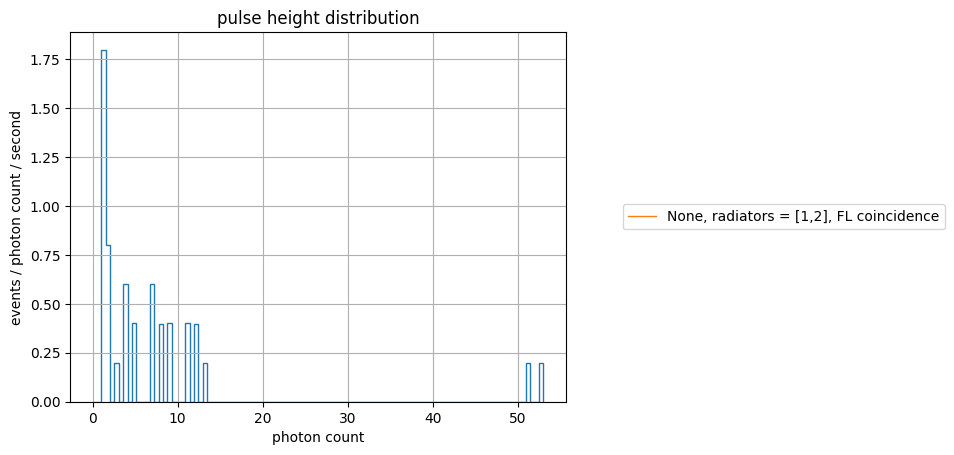

In [42]:
IRENE8_450_electrons_orbital_run.run_dict[832].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
IRENE8_450_electrons_orbital_run.run_dict[832].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

In [43]:
IRENE8_450_electrons_orbital_run.run_dict[832].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)

0.7273088585955116+/-0.27489690945399514

In [44]:
IRENE8_450_electrons_orbital_run.run_dict[832].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)

0.0+/-0.10390126551364452

In [45]:
IRENE8_450_protons_differential_single_orbit = IRENE8_450_protons_differential.iloc[790:850].sample(60,random_state=1).sort_index()
IRENE8_450_protons_differential_single_orbit.head()


,Latitude_deg,Longitude_deg,125.0,175.0,250.0,350.0
790,84.29629,156.896069,-0.0,-0.0,-0.0,-0.0
791,87.57371,156.643162,-0.0,-0.0,-0.0,-0.0
792,89.14890,336.407396,-0.0,-0.0,-0.0,-0.0
793,85.87130,336.147949,-0.0,-0.0,-0.0,-0.0
794,82.59322,335.896262,-0.0,-0.0,-0.0,-0.0


In [46]:
IRENE8_450_protons_original_differential_single_orbit = IRENE8_450_protons_original_differential.iloc[790:850].sample(60,random_state=1).sort_index()
IRENE8_450_protons_original_differential_single_orbit.head()

,Latitude_deg,Longitude_deg,0.125,0.175,0.25,0.35,0.45,0.55,0.65,0.85,...,25.0,35.0,45.0,55.0,65.0,85.0,125.0,175.0,250.0,350.0
790,84.29629,156.896069,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
791,87.57371,156.643162,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
792,89.14890,336.407396,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
793,85.87130,336.147949,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
794,82.59322,335.896262,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [47]:
IRENE8_450_protons_orbital_run = orbital_run(IRENE8_450_protons_differential_single_orbit, 
                                            particle_species="proton",
                                            #number_of_particles_to_simulate=1_000_000,
                                            #number_of_particles_to_simulate=100_000,
                                            number_of_particles_to_simulate=20_000,
                                            label="AP8 protons",
                                            threshold_photon_value=20.0,
                                            ignore_coincidence_horns_regions=False)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/home/xisacross/programming/HEPI/.venv/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectr

/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].

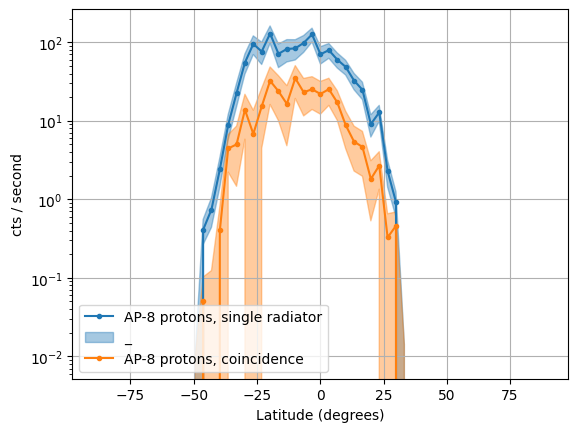

In [48]:
IRENE8_450_protons_orbital_run.plot_single_rad_run_dict(xvalues_to_use = "latitudes",error_bar_function=fill_between_errorbar)
IRENE8_450_protons_orbital_run.plot_run_dict(xvalues_to_use = "latitudes",error_bar_function=fill_between_errorbar)
plt.legend(["AP-8 protons, single radiator","_","AP-8 protons, coincidence"])

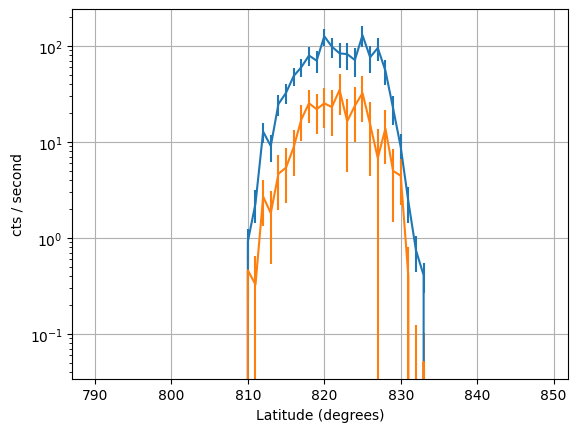

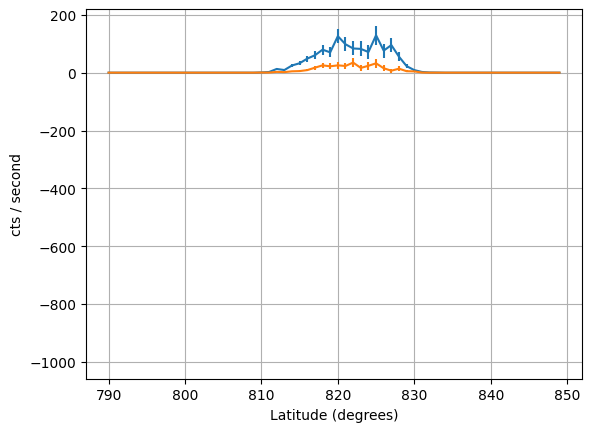

In [49]:
IRENE8_450_protons_orbital_run.plot_single_rad_run_dict()
IRENE8_450_protons_orbital_run.plot_run_dict()

plt.figure()

IRENE8_450_protons_orbital_run.plot_single_rad_run_dict()
IRENE8_450_protons_orbital_run.plot_run_dict()

plt.yscale("linear")

In [50]:
dir(IRENE8_450_protons_orbital_run)

['DF_of_coordinates_and_spectra',
 '__add__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'ignore_coincidence_horns_regions',
 'label',
 'plot_run_dict',
 'plot_single_rad_run_dict',
 'print_count_rates_info',
 'run_Cherenkov_simulation_across_row',
 'run_dict',
 'run_dict_event_counts',
 'single_rad_run_dict_event_counts']

In [51]:
IRENE8_450_protons_orbital_run.run_dict

{790: 0.0+/-0,
 791: 0.0+/-0,
 792: 0.0+/-0,
 793: 0.0+/-0,
 794: 0.0+/-0,
 795: 0.0+/-0,
 796: 0.0+/-0,
 797: 0.0+/-0,
 798: 0.0+/-0,
 799: 0.0+/-0,
 800: 0.0+/-0,
 801: 0.0+/-0,
 802: 0.0+/-0,
 803: 0.0+/-0,
 804: 0.0+/-0,
 805: 0.0+/-0,
 806: 0.0+/-0,
 807: 0.0+/-0,
 808: 0.0+/-0,
 809: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b819a780>,
 810: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b81ded50>,
 811: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3d43c20>,
 812: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3d83aa0>,
 813: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3db5df0>,
 814: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b8279580>,
 815: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3c37e00>,
 816: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3c83d10>,
 817: <spectra_running_tools.gras_Cherenkov

In [52]:
IRENE8_450_protons_orbital_run.run_dict

{790: 0.0+/-0,
 791: 0.0+/-0,
 792: 0.0+/-0,
 793: 0.0+/-0,
 794: 0.0+/-0,
 795: 0.0+/-0,
 796: 0.0+/-0,
 797: 0.0+/-0,
 798: 0.0+/-0,
 799: 0.0+/-0,
 800: 0.0+/-0,
 801: 0.0+/-0,
 802: 0.0+/-0,
 803: 0.0+/-0,
 804: 0.0+/-0,
 805: 0.0+/-0,
 806: 0.0+/-0,
 807: 0.0+/-0,
 808: 0.0+/-0,
 809: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b819a780>,
 810: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b81ded50>,
 811: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3d43c20>,
 812: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3d83aa0>,
 813: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3db5df0>,
 814: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b8279580>,
 815: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3c37e00>,
 816: <spectra_running_tools.gras_Cherenkov_runner_from_objects at 0x7f12b3c83d10>,
 817: <spectra_running_tools.gras_Cherenkov

In [53]:
IRENE8_450_protons_orbital_run.run_dict[809].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20)

0.0+/-0.014194469591155546

In [54]:
dir(IRENE8_450_protons_orbital_run.run_dict[809].outputted_tuple)

['Cherenkov_run_label',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_more_columns_to_generated_photons_DF',
 'coincidence_tuple_dictionary',
 'construct_hits_dictionary',
 'convert_to_theta_phi_DF',
 'determine_pulse_height_distributions',
 'generated_photons_DF',
 'generated_primary_DF',
 'get_coincidence_DF',
 'get_coincidence_events',
 'get_coincidence_tuple',
 'get_fractions_of_particle_types',
 'get_photon_wavelength_nm',
 'get_relevant_hit_key',
 'hits',
 'incoming_particles_per_second',
 'number_of_events_simulated',
 'output_tuples',
 'plot_coincidence_pulse_height_distribution',
 'plot_differential_primary_spectra',
 'plot_integral_pri

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


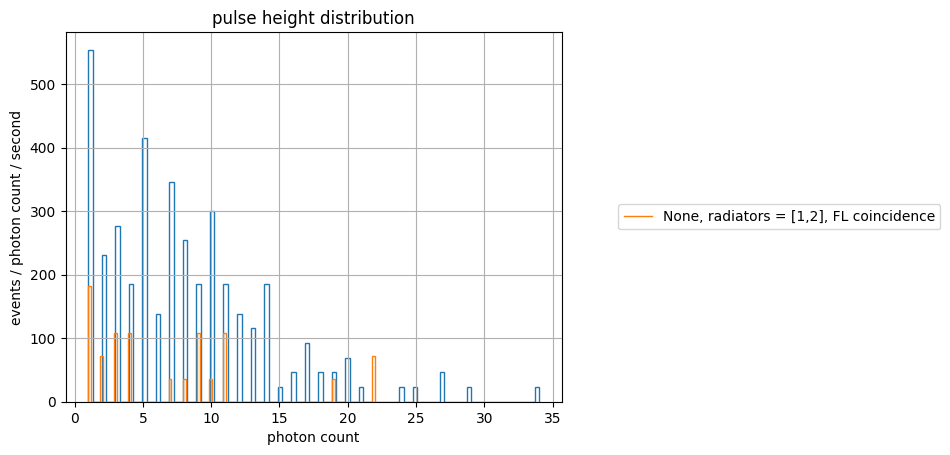

In [55]:
IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

In [56]:
dir(IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'])

['Cherenkov_run_label',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_more_columns_to_generated_photons_DF',
 'determine_pulse_height_distributions',
 'get_fractions_of_particle_types',
 'get_photon_wavelength_nm',
 'incoming_particles_per_second',
 'number_of_events_simulated',
 'plot_differential_primary_spectra',
 'plot_integral_primary_spectra',
 'plot_pulse_height_distribution',
 'plot_smoother_pulse_height_distribution',
 'primary_particle_Cherenkov_tuple',
 'pulse_height_distribution_averaged_method',
 'pulse_height_distribution_monte_carlo',
 'random_reject_pde',
 'secondary_particle_Cherenkov_tuple',
 'threshold_primary_energy']

In [57]:
IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)


464.8634378718681+/-59.51966417999362

In [58]:
IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)

53.344984673820925+/-20.16250901992603

In [59]:
IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

15.241424192520265+/-10.777314401471779

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz

/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].

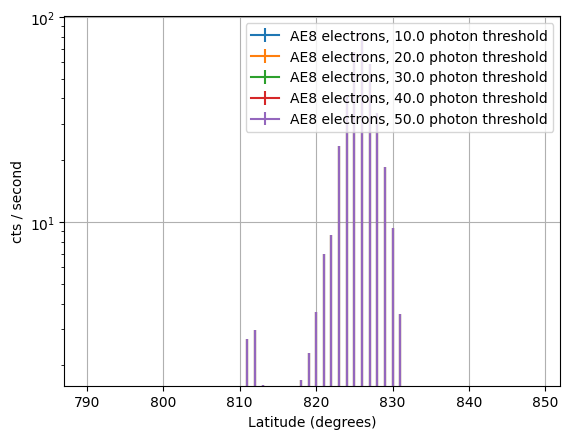

In [60]:
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit, 
                particle_species="e-",
                label=f"AE8 electrons, {photon_threshold} photon threshold",
                threshold_photon_value=photon_threshold).plot_run_dict()
plt.legend()

0it [00:00, ?it/s]

/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].

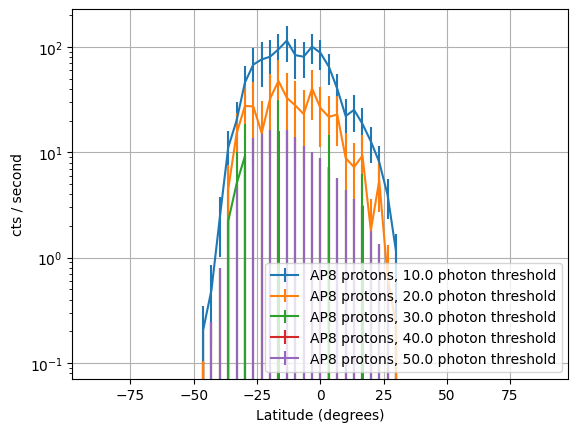

In [61]:
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    orbital_run(IRENE8_450_protons_differential_single_orbit, 
                particle_species="proton",
                #number_of_particles_to_simulate=1_000_000,
                number_of_particles_to_simulate=10_000,
                label=f"AP8 protons, {photon_threshold} photon threshold",
                threshold_photon_value=photon_threshold).plot_run_dict(xvalues_to_use="latitudes")#,error_bar_function=fill_between_errorbar)
plt.legend()

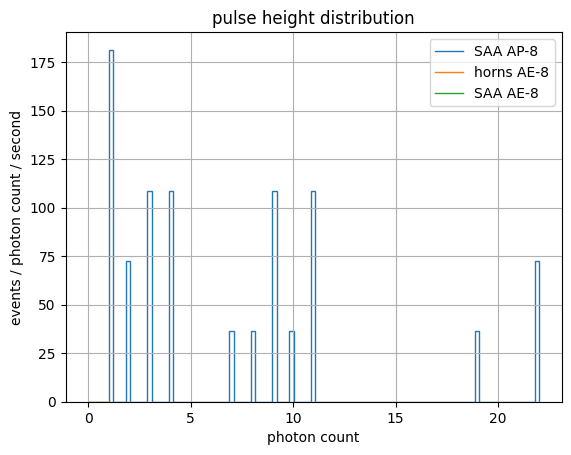

In [62]:
IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution()
IRENE8_450_electrons_orbital_run.run_dict[index_for_horns_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution()
IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution()

plt.legend(["SAA AP-8","horns AE-8","SAA AE-8"])

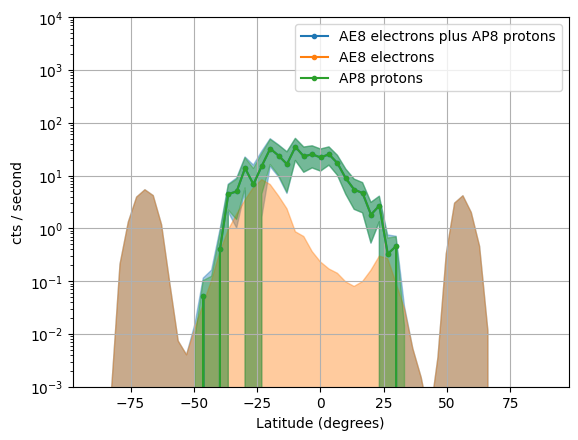

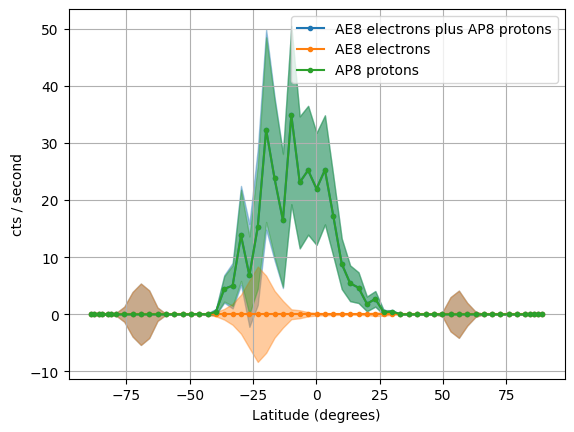

In [63]:
(IRENE8_450_electrons_orbital_run + IRENE8_450_protons_orbital_run).plot_run_dict(xvalues_to_use="latitudes", error_bar_function=fill_between_errorbar)
IRENE8_450_electrons_orbital_run.plot_run_dict(xvalues_to_use="latitudes", error_bar_function=fill_between_errorbar)
IRENE8_450_protons_orbital_run.plot_run_dict(xvalues_to_use="latitudes", error_bar_function=fill_between_errorbar)
plt.legend()
#plt.legend(["total","electrons","protons"])
plt.ylim([1e-3,1e4])
save_figure_for_paper("HEPI_background_output_coincidence")

plt.figure()
(IRENE8_450_electrons_orbital_run + IRENE8_450_protons_orbital_run).plot_run_dict(xvalues_to_use="latitudes", error_bar_function=fill_between_errorbar)
IRENE8_450_electrons_orbital_run.plot_run_dict(xvalues_to_use="latitudes", error_bar_function=fill_between_errorbar)
IRENE8_450_protons_orbital_run.plot_run_dict(xvalues_to_use="latitudes", error_bar_function=fill_between_errorbar)
#plt.legend(["total","electrons","protons"])
plt.legend()
plt.yscale("linear")

In [64]:
default_rigidities = np.concatenate([[0,1,2,3,4],np.linspace(5,20,5)])

In [65]:
GLE21_spectrum = SRT.particle_spectrum(particle_species=SRT.particle("proton"),
                                        spectrum_file_path="GLE21spectrum_multipliedby1.csv",
                                        incoming_particles_per_s_per_cm2=SRT.GLE21_integral_count_rate)

GLE05_spectrum = SRT.particle_spectrum(particle_species=SRT.particle("proton"),
                                        spectrum_file_path="GLE05spectrum_multipliedby1.csv",
                                        incoming_particles_per_s_per_cm2=SRT.GLE05_integral_count_rate)

In [66]:
array_of_GCR_rig_cutoff_runs =np.array([[rigidity_cut_off_GV,
                                         SRT.get_GCR_Cherenkov_run_rigidity_cut_off(rigidity_cut_off_GV,
                                                                                    datetime_to_use=SRT.datetime_for_GCR_solar_max)] for rigidity_cut_off_GV in default_rigidities])

In [67]:
array_of_GLE21_rig_cutoff_runs =np.array([[rigidity_cut_off_GV,
                                           SRT.get_GLE_Cherenkov_run_rigidity_cut_off(rigidity_cut_off_GV,
                                                                                      GLE_spec=GLE21_spectrum)] for rigidity_cut_off_GV in default_rigidities])

In [68]:
array_of_GLE21_rig_cutoff_runs

array([[np.float64(0.0),
       [np.float64(1.0),
       [np.float64(2.0),
       [np.float64(3.0),
       [np.float64(4.0),
       [np.float64(5.0),
       [np.float64(8.75),
       [np.float64(12.5),
       [np.float64(16.25),
       [np.float64(20.0),
      dtype=object)

In [69]:
array_of_GLE05_rig_cutoff_runs =np.array([[rigidity_cut_off_GV,SRT.get_GLE_Cherenkov_run_rigidity_cut_off(rigidity_cut_off_GV,GLE_spec=GLE05_spectrum)] for rigidity_cut_off_GV in default_rigidities])

In [70]:
from AsympDirsCalculator import AsympDirsTools
from scipy.interpolate import interp1d
import datetime as dt

/home/xisacross/programming/HEPI/.venv/lib/python3.12/site-packages/AsympDirsCalculator/MAGCOSmacroFileGenerator.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [71]:
def uncertainty_interp1d(x, y, **kwargs):

    n_interp = interp1d(x,[uy_value.n for uy_value in y], **kwargs)
    std_dev_interp = interp1d(x,[uy_value.std_dev for uy_value in y], **kwargs)

    return lambda x_arg:(ufloat(n_interp(x_arg),std_dev_interp(x_arg)) if np.isscalar(x_arg) else unumpy.uarray(n_interp(x_arg),std_dev_interp(x_arg)))

In [72]:
acquire_count_rate_multi = np.vectorize(lambda output_run,threshold_photon_value=10.0:output_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=threshold_photon_value))


In [73]:
class multi_rigidity_run():

    def __init__(self, rigidity_run_class, array_of_rigidities_GV=default_rigidities, input_DF_of_coords=None, label=None, threshold_photon_value=10.0, **kwargs):

        self.label = label

        if input_DF_of_coords is None:
            self.array_of_lats_and_longs = np.linspace([-90,0],[90,0],100)
        else:
            self.array_of_lats_and_longs = input_DF_of_coords[["Latitude_deg","Longitude_deg"]].to_numpy()

        self.array_of_rig_cutoff_runs =np.array([[rigidity_cut_off_GV,
                                                  rigidity_run_class(rigidity_cut_off_GV,**kwargs)] for rigidity_cut_off_GV in array_of_rigidities_GV])

        self.array_of_count_rates = np.transpose([self.array_of_rig_cutoff_runs[:,0],
                                                  acquire_count_rate_multi(self.array_of_rig_cutoff_runs[:,1],threshold_photon_value=threshold_photon_value)])
                                                  #SRT.acquire_count_rate(self.array_of_rig_cutoff_runs[:,1],threshold_photon_value=threshold_photon_value)])

        # self.rig_interp = interp1d(self.array_of_count_rates[:,0], 
        #                       np.vectorize(lambda x:x.nominal_value)(self.array_of_count_rates[:,1]),
        #                       fill_value="extrapolate")
        self.rig_interp = uncertainty_interp1d(self.array_of_count_rates[:,0], 
                              (self.array_of_count_rates[:,1]),
                              fill_value="extrapolate")

    def plot_count_rates(self):

        SRT.error_bar_from_array(self.array_of_count_rates)
        plt.xlabel("Cut-off rigidity (GV)")
        plt.ylabel("cts / second")

    def get_count_rates_for_coord_array(self, array_of_lats_and_longs:np.array, datetime_for_rigidities=SRT.datetime_for_GCR_solar_max):

        vcutoffs_to_compare_to = AsympDirsTools.get_magcos_vcutoffs(array_of_lats_and_longs = array_of_lats_and_longs,
                                 dateAndTime=datetime_for_rigidities,cache=True)
        vcutoffs_to_compare_to = vcutoffs_to_compare_to[
            #np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != -81.194370) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != 72.753770) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != -56.147930) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != -69.295260) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != 39.842640) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != 42.992710) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != -3.229399) &
            np.array(vcutoffs_to_compare_to.reset_index()["initialLatitude"] != 33.233800)]  
        vcutoffs_to_compare_to.iloc[5] = vcutoffs_to_compare_to.iloc[4]

        DF_of_count_rates = vcutoffs_to_compare_to["Reffective"].apply(self.rig_interp).reset_index().rename(columns={"Reffective":"count rate"})

        return DF_of_count_rates

    def plot_count_rates_against_longitude_0(self, datetime_for_rigidities=SRT.datetime_for_GCR_solar_max,plot_error_bars=False,**kwargs):

        DF_of_count_rates = self.get_count_rates_for_coord_array(array_of_lats_and_longs = self.array_of_lats_and_longs, 
                                                            datetime_for_rigidities=datetime_for_rigidities)
        
        series_of_latitudes = DF_of_count_rates["initialLatitude"]
        series_of_count_rates = DF_of_count_rates["count rate"].apply(lambda x:x.n)
        series_of_count_rates_errs = DF_of_count_rates["count rate"].apply(lambda x:x.std_dev)
        
        if plot_error_bars == True:
            plt.errorbar(series_of_latitudes,
                        series_of_count_rates,
                        series_of_count_rates_errs,
                        label=self.label,**kwargs)
        else:
            # plt.plot(series_of_latitudes,
            #             series_of_count_rates,
            #             label=self.label,
            #             marker="o",
            #             ms=3,
            #             **kwargs)
            # plt.fill_between(series_of_latitudes,
            #             series_of_count_rates - series_of_count_rates_errs,
            #             series_of_count_rates + series_of_count_rates_errs,
            #             color=plt.gca().lines[-1].get_color(),
            #             alpha=0.4,
            #             label=self.label)
            
            fill_between_errorbar(series_of_latitudes,
                        series_of_count_rates,
                        series_of_count_rates_errs,
                        label=self.label,**kwargs)

        plt.xlabel("Latitude (degrees)")
        plt.ylabel("cts / second")
        plt.grid(True)

    def get_int_time_array(self,background_multi_rigidity_run=0):

        if background_multi_rigidity_run == 0:
            bkg_array_of_count_rates = np.zeros(np.shape(self.array_of_count_rates))
        elif isinstance(background_multi_rigidity_run,SRT.gras_Cherenkov_runner_from_objects):
            bkg_array_of_count_rates = np.full(np.shape(self.array_of_count_rates),background_multi_rigidity_run.get_total_photon_inducing_event_count_per_second())
        else:
            bkg_array_of_count_rates = background_multi_rigidity_run.array_of_count_rates

        int_time_array = np.array([[self.array_of_count_rates[index,0],
                                    SRT.get_integration_time_for_sigma(3,self.array_of_count_rates[index,1],
                                    bkg_array_of_count_rates[index,1])] for index in range(0,len(self.array_of_count_rates))])

        return int_time_array

    def plot_int_time_array(self,background_multi_rigidity_run=0):

        int_time_array = self.get_int_time_array(background_multi_rigidity_run)

        SRT.error_bar_from_array(int_time_array, label=self.label)

        plt.axhline(60,ls="--")
        plt.xlabel("Cut-off rigidity (GV)")
        plt.ylabel("required integration time\nfor 3 sigma certainty")
        plt.ylim([0.1,1000])
        plt.yscale("log")

    def get_count_rates_for_int_time_array(self, 
                                           array_of_lats_and_longs:np.array, 
                                           datetime_for_rigidities=SRT.datetime_for_GCR_solar_max, 
                                           background_multi_rigidity_run=0):

        vcutoffs_to_compare_to = AsympDirsTools.get_magcos_vcutoffs(array_of_lats_and_longs = array_of_lats_and_longs,
                                 dateAndTime=datetime_for_rigidities,cache=True)

        int_time_array = self.get_int_time_array(background_multi_rigidity_run)

        time_array_rig_interp = uncertainty_interp1d(int_time_array[:,0], 
                              (int_time_array[:,1]))

        DF_of_int_times = vcutoffs_to_compare_to["Reffective"].apply(time_array_rig_interp).reset_index().rename(columns={"Reffective":"int time"})

        return DF_of_int_times

    def plot_int_time_array_vs_longitude_0(self,
                                           datetime_for_rigidities=SRT.datetime_for_GCR_solar_max,
                                           background_multi_rigidity_run=0,
                                           plot_error_bars=False,
                                           **kwargs):

        DF_of_int_times = self.get_count_rates_for_int_time_array(array_of_lats_and_longs = self.array_of_lats_and_longs, 
                                                            datetime_for_rigidities=datetime_for_rigidities,
                                                            background_multi_rigidity_run=background_multi_rigidity_run)
        
        series_of_latitudes = DF_of_int_times["initialLatitude"]
        series_of_int_times = DF_of_int_times["int time"].apply(lambda x:x.n)
        series_of_int_times_errs = DF_of_int_times["int time"].apply(lambda x:x.std_dev)

        #DF_of_int_times.plot("initialLatitude","int time",ax=plt.gca())
        if plot_error_bars == True:
            plt.errorbar(series_of_latitudes,
                        series_of_int_times,
                        series_of_int_times_errs,
                        label=self.label,**kwargs)
        else:
            # plt.plot(series_of_latitudes,
            #             series_of_int_times,
            #             label=self.label,
            #             marker="o",
            #             ms=3,
            #             **kwargs)
            # plt.fill_between(series_of_latitudes,
            #             series_of_int_times - series_of_int_times_errs,
            #             series_of_int_times + series_of_int_times_errs,
            #             color=plt.gca().lines[-1].get_color(),
            #             alpha=0.4,
            #             label=self.label)
            
            fill_between_errorbar(series_of_latitudes,
                        series_of_int_times,
                        series_of_int_times_errs,
                        label=self.label,**kwargs)

        plt.axhline(60,ls="--")
        plt.xlabel("Latitude (degrees)")
        plt.ylabel("required integration time (s)\nfor 3 sigma certainty")
        plt.ylim([0.1,1000])
        plt.yscale("log")
        plt.grid()



running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...


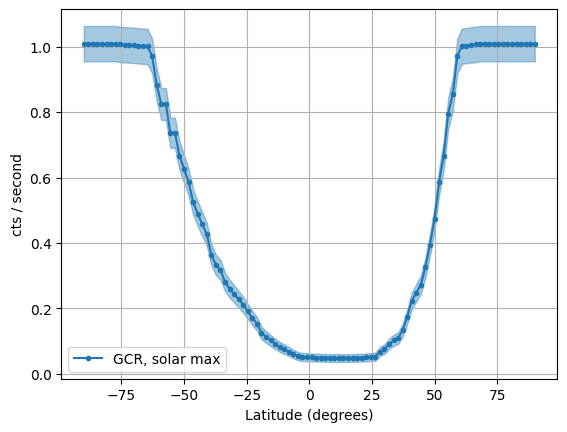

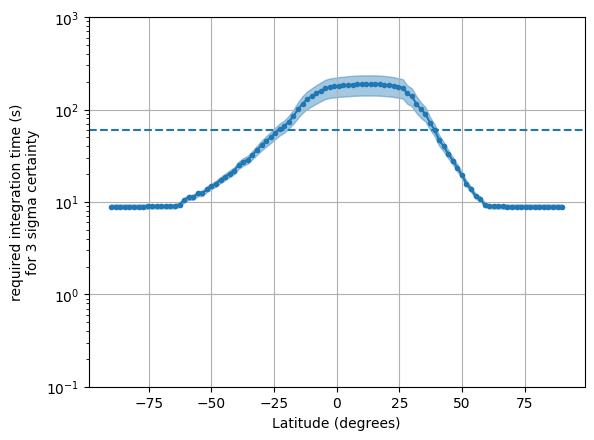

In [74]:
GCR_max_multi_rig_run = multi_rigidity_run(SRT.get_GCR_Cherenkov_run_rigidity_cut_off,
                                            datetime_to_use=SRT.datetime_for_GCR_solar_max, 
                                            #input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]], 
                                            threshold_photon_value=20.0, 
                                            label = "GCR, solar max",
                                           number_of_radiators=2)
GCR_max_multi_rig_run.plot_count_rates_against_longitude_0()
plt.legend()
plt.figure()
GCR_max_multi_rig_run.plot_int_time_array_vs_longitude_0() #marker="o",ms=3,mfc="black",ecolor="black")

running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...


(0.1, 10000.0)

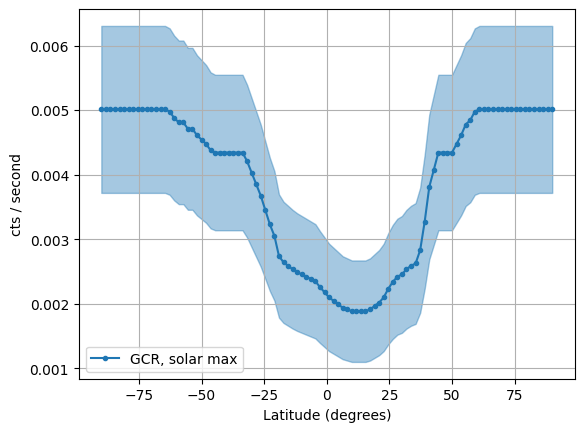

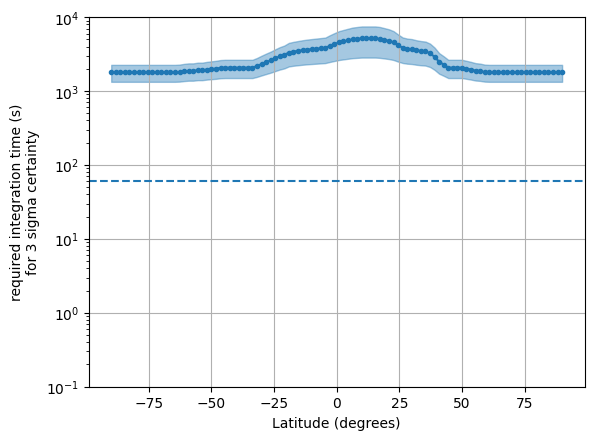

In [75]:
alpha_GCR_max_multi_rig_run = multi_rigidity_run(SRT.get_GCR_Cherenkov_run_rigidity_cut_off,
                                            datetime_to_use=SRT.datetime_for_GCR_solar_max,
                                            #input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]], 
                                            threshold_photon_value=20.0,
                                            label = "GCR, solar max",
                                            atomic_number_for_cosmic_rays = 2,
                                            number_of_radiators=2)
alpha_GCR_max_multi_rig_run.plot_count_rates_against_longitude_0()
plt.legend()
plt.figure()
alpha_GCR_max_multi_rig_run.plot_int_time_array_vs_longitude_0() #marker="o",ms=3,mfc="black",ecolor="black")
plt.ylim([1e-1,1e4])

In [76]:
alpha_GCR_max_multi_rig_run.array_of_rig_cutoff_runs

array([[np.float64(0.0),
       [np.float64(1.0),
       [np.float64(2.0),
       [np.float64(3.0),
       [np.float64(4.0),
       [np.float64(5.0),
       [np.float64(8.75),
       [np.float64(12.5),
       [np.float64(16.25),
       [np.float64(20.0),
      dtype=object)

In [77]:
alpha_GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.3577102252470316+/-0.010930414195185893

In [78]:
alpha_GCR_max_multi_rig_run.array_of_count_rates

array([[np.float64(0.0), 0.0050099471323113666+/-0.0012935627872547688],
       [np.float64(1.0), 0.0050099471323113666+/-0.0012935627872547688],
       [np.float64(2.0), 0.004675950656823942+/-0.0012497003796639835],
       [np.float64(3.0), 0.004341954181336518+/-0.0012042414181941603],
       [np.float64(4.0), 0.004341954181336518+/-0.0012042414181941603],
       [np.float64(5.0), 0.004341954181336518+/-0.0012042414181941603],
       [np.float64(8.75), 0.002671971803899396+/-0.0009446846908382575],
       [np.float64(12.5), 0.002337975328411971+/-0.0008836716129118058],
       [np.float64(16.25), 0.001335985901949698+/-0.000667992950974849],
       [np.float64(20.0), 0.0010019894264622733+/-0.0005784988650931523]],
      dtype=object)

In [79]:
alpha_GCR_max_multi_rig_run.rig_interp(0.0)

0.0050099471323113666+/-0.0012935627872547688

## testing coincidence normalisation

In [80]:
dir(GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'calculate_Cherenkov_tuple',
 'directory_to_run_in',
 'generated_geometry',
 'generated_macro',
 'generation_surface_area_cm2',
 'generation_surface_radius',
 'get_particle_spectrum_and_generate_GRAS_file',
 'get_total_photon_inducing_event_count_per_second',
 'incoming_particles_per_s',
 'initialise_dir_and_copy_geom_and_mac_files',
 'initialise_output_gras_directory',
 'initialise_running_directory_and_macro',
 'outputted_tuple',
 'plot_pulse_height_distribution',
 'run_gras_simulation',
 'setup_input_variables',
 'verbose_output']

In [81]:
single_radiator_run = SRT.wrapper_GCR_Cherenkov_runner(datetime_for_GCR=SRT.datetime_for_GCR_solar_max,
                                           number_of_radiators=1,
                                           number_of_particles=10_010)

In [82]:
single_radiator_run.incoming_particles_per_s

np.float64(29.005043285823753)

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


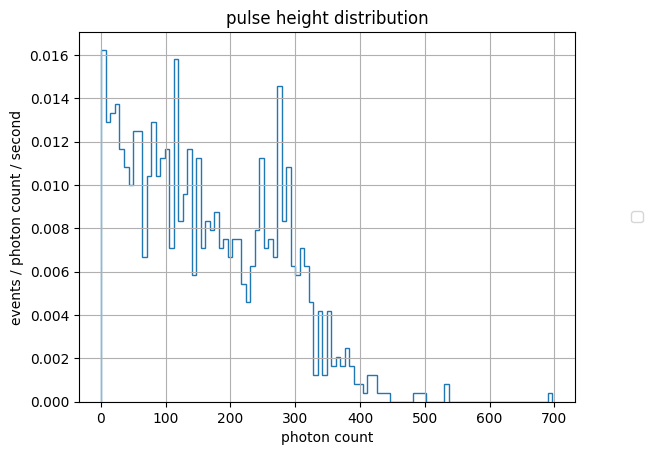

In [83]:
single_radiator_run.outputted_tuple.plot_pulse_height_distribution()

In [84]:
alpha_single_radiator_run = SRT.wrapper_GCR_Cherenkov_runner(datetime_for_GCR=SRT.datetime_for_GCR_solar_max,
                                           number_of_radiators=1,
                                           atomic_number_for_cosmic_rays = 2,
                                           number_of_particles=10_010)

In [85]:
alpha_single_radiator_run.incoming_particles_per_s

np.float64(3.3399647548742446)

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


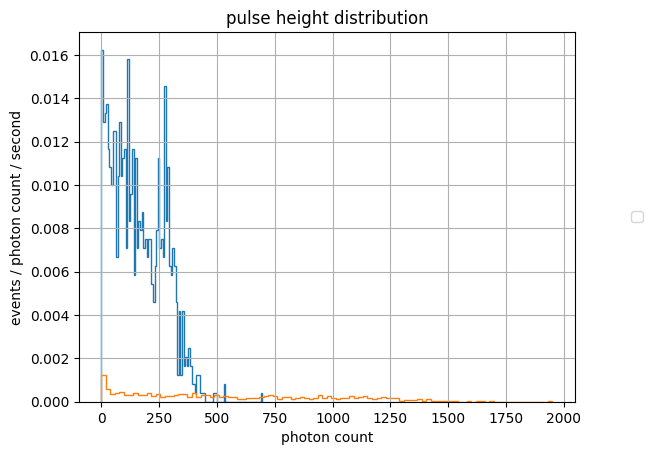

In [86]:
single_radiator_run.outputted_tuple.plot_pulse_height_distribution()
alpha_single_radiator_run.outputted_tuple.plot_pulse_height_distribution()

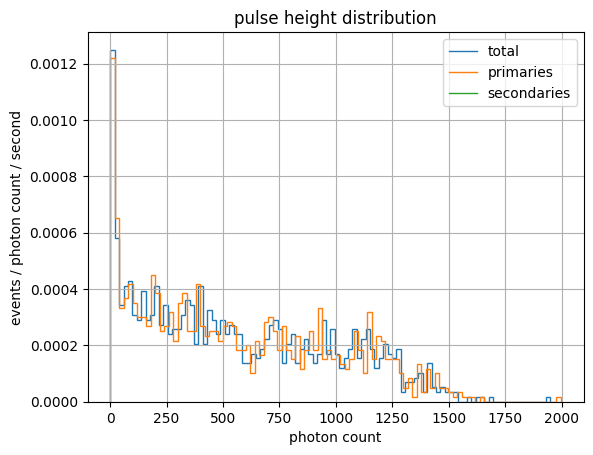

In [87]:
alpha_single_radiator_run.outputted_tuple.plot_pulse_height_distribution()
alpha_single_radiator_run.outputted_tuple.primary_particle_Cherenkov_tuple.plot_pulse_height_distribution()
alpha_single_radiator_run.outputted_tuple.secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution()
plt.legend(["total","primaries","secondaries"])

In [88]:
single_radiator_run.outputted_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

2.9642516764633067+/-0.09267812893561446

In [89]:
alpha_single_radiator_run.outputted_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.32932519610997796+/-0.0104825364878315

In [90]:
single_radiator_run.outputted_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0) / \
    alpha_single_radiator_run.outputted_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

9.000986597677137+/-0.40159819349920123

In [91]:
GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1].incoming_particles_per_s

np.float64(29.005043285823753)

In [92]:
dir(single_radiator_run.outputted_tuple)

['Cherenkov_run_label',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'add_more_columns_to_generated_photons_DF',
 'determine_pulse_height_distributions',
 'get_fractions_of_particle_types',
 'get_photon_wavelength_nm',
 'incoming_particles_per_second',
 'number_of_events_simulated',
 'plot_differential_primary_spectra',
 'plot_integral_primary_spectra',
 'plot_pulse_height_distribution',
 'plot_smoother_pulse_height_distribution',
 'primary_particle_Cherenkov_tuple',
 'pulse_height_distribution_averaged_method',
 'pulse_height_distribution_monte_carlo',
 'random_reject_pde',
 'secondary_particle_Cherenkov_tuple',
 'threshold_primar

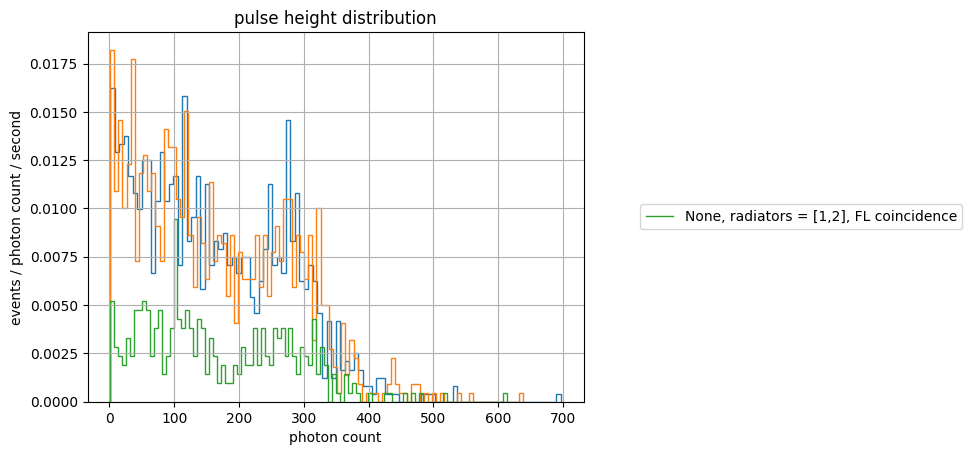

In [93]:
single_radiator_run.outputted_tuple.plot_pulse_height_distribution()
GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

In [94]:
GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)


3.129644170540383+/-0.09527615894637534

In [95]:
3 * GCR_max_multi_rig_run.array_of_rig_cutoff_runs[0,1].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)

3.115141648897471+/-0.16464035201105184

In [96]:
single_radiator_run = SRT.GCR_Cherenkov_runner(datetime_for_GCR=SRT.datetime_for_GCR_solar_max,
                                           number_of_radiators=1,
                                           #verbose_output=True,
                                           save_DF_of_output_hits = True)

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


In [97]:
single_radiator_run.outputted_tuple.secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.0+/-0.002900504328582375

In [98]:
multi_radiator_run = SRT.GCR_Cherenkov_runner(datetime_for_GCR=SRT.datetime_for_GCR_solar_max,
                                           number_of_radiators=2,
                                           #verbose_output=True,
                                           save_DF_of_output_hits = True)

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

...

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})


In [99]:
dir(single_radiator_run)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'calculate_Cherenkov_tuple',
 'directory_to_run_in',
 'generated_geometry',
 'generated_macro',
 'generation_surface_area_cm2',
 'generation_surface_radius',
 'get_particle_spectrum_and_generate_GRAS_file',
 'get_total_photon_inducing_event_count_per_second',
 'incoming_particles_per_s',
 'initialise_dir_and_copy_geom_and_mac_files',
 'initialise_output_gras_directory',
 'initialise_running_directory_and_macro',
 'outputted_tuple',
 'plot_pulse_height_distribution',
 'run_gras_simulation',
 'setup_input_variables',
 'verbose_output']

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


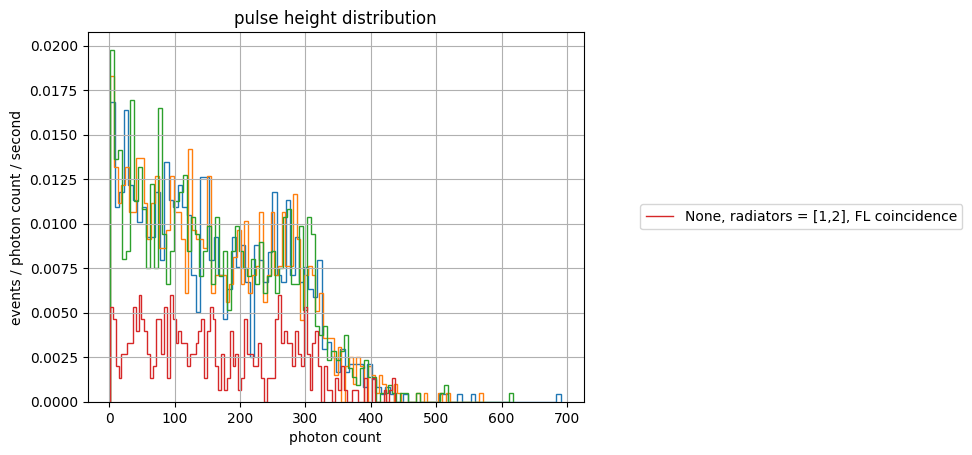

In [100]:
single_radiator_run.outputted_tuple.plot_pulse_height_distribution()
multi_radiator_run.outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
multi_radiator_run.outputted_tuple.output_tuples['RA1_tuple_interaction;1'].plot_pulse_height_distribution()
multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

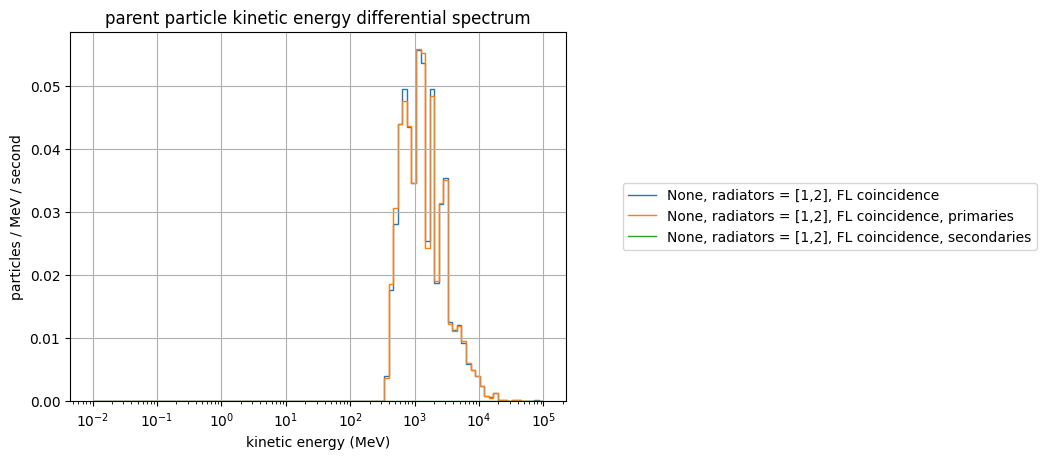

In [101]:
multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_differential_primary_spectra()
multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].primary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].secondary_particle_Cherenkov_tuple.plot_differential_primary_spectra()

In [102]:
np.min(multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.kinetic_energies_series)

np.float32(336.08783)

In [103]:
np.min(multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].primary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.kinetic_energies_series)

np.float32(336.08783)

In [104]:
np.max(multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.kinetic_energies_series)

nan

In [105]:
multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"]

In [106]:
single_radiator_run.outputted_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=10.0)

3.0716340839687355+/-0.09438902455461903

In [107]:
multi_radiator_run.outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.9948729847037547+/-0.05371809191066738

In [108]:
single_radiator_run.outputted_tuple.DF_of_output_hits

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
1,414,-22,0.000004,5697.950195,0.000004,330.956238,0.462352
2,414,-22,0.000005,5697.950195,0.000005,255.342270,0.128550
3,414,-22,0.000004,5697.950195,0.000004,343.933807,0.474560
4,414,-22,0.000002,5697.950195,0.000002,700.348816,0.262580
5,414,-22,0.000005,5697.950195,0.000005,238.967178,0.090513
...,...,...,...,...,...,...,...
611102,9596,-22,0.000006,1504.347046,0.000006,206.574921,0.015272
611103,9596,-22,0.000003,1504.347046,0.000003,395.875793,0.595981
611104,9596,-22,0.000006,1504.347046,0.000006,202.693024,0.006255
611105,9596,-22,0.000002,1504.347046,0.000002,529.466003,0.468827


In [109]:
multi_radiator_run.outputted_tuple.output_tuples['RA1_tuple_interaction;1'].DF_of_output_hits

,event_id,particle_id,kinetic_energy,total_energy,primary_kinetic_energy,wavelength_nm,Si_detection_probability
1,277,-22,NaN,0.000004,1039.468750,343.474030,0.473587
2,277,-22,0.000005,0.000005,1039.468750,247.914001,0.111295
3,277,-22,NaN,0.000003,1039.468750,399.821045,0.597801
4,277,-22,NaN,0.000002,1039.468750,766.745605,0.087693
5,277,-22,NaN,0.000006,1039.468750,204.732513,0.010993
...,...,...,...,...,...,...,...
628108,9524,-22,0.000003,0.000003,10900.952148,468.406036,0.523568
628109,9524,-22,NaN,0.000005,10900.952148,248.243256,0.112060
628110,9524,-22,NaN,0.000003,10900.952148,403.463959,0.598110
628111,9524,-22,0.000006,0.000006,10900.952148,212.680130,0.029454


In [110]:
multi_radiator_run.outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].DF_of_output_hits

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
1,277,-22,0.000004,1044.511475,0.000004,315.083282,0.446359
2,277,-22,0.000003,1044.511475,0.000003,465.274384,0.525919
3,277,-22,0.000002,1044.511475,0.000002,649.060242,0.324443
4,277,-22,0.000003,1044.511475,0.000003,397.551178,0.596754
5,277,-22,0.000005,1044.511475,0.000005,257.564270,0.133711
...,...,...,...,...,...,...,...
610862,9524,-22,0.000002,10904.815430,0.000002,629.632996,0.347876
610863,9524,-22,0.000005,10904.815430,0.000005,241.651810,0.096749
610864,9524,-22,0.000005,10904.815430,0.000005,236.101334,0.083856
610865,9524,-22,0.000004,10904.815430,0.000004,278.693726,0.182790


In [111]:
IRENE8_450_electrons_differential_shortened_single_orbit.head()

,Latitude_deg,Longitude_deg,1.125,1.375,1.625,1.875,2.125,2.375,2.625,2.875,...,3.625,3.875,4.125,4.375,4.625,4.875,5.25,5.75,6.25,6.75
790,84.29629,156.896069,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
791,87.57371,156.643162,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
792,89.14890,336.407396,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
793,85.87130,336.147949,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
794,82.59322,335.896262,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [112]:
test_single_IRENE8_450_electrons_orbital_run = orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit[IRENE8_450_electrons_differential_shortened_single_orbit.index == index_for_SAA_max], 
                                               particle_species="e-",
                                               number_of_particles_to_simulate=1_000_001,
                                               label="AE8 electrons",
                                               threshold_photon_value=20.0,
                                               save_DF_of_output_hits = True)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12b0a9a240>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=1000001, number_of_radiators=2, save_DF_of_output_hits=True)


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
_____________________wrapper_gras_Cherenkov_runner_from_objects - 181.8s, 3.0min


1it [00:00, 223.16it/s]


In [113]:
test_single_IRENE8_450_electrons_orbital_run_slight_short = orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit[IRENE8_450_electrons_differential_shortened_single_orbit.columns[:-1]][IRENE8_450_electrons_differential_shortened_single_orbit.index == index_for_SAA_max], 
                                               particle_species="e-",
                                               number_of_particles_to_simulate=100_001,
                                               label="AE8 electrons",
                                               threshold_photon_value=20.0,
                                               save_DF_of_output_hits = True)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a6e62f60>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=100001, number_of_radiators=2, save_DF_of_output_hits=True)


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


1it [00:21, 21.47s/it]


______________________wrapper_gras_Cherenkov_runner_from_objects - 21.5s, 0.4min


1it [00:00, 2805.55it/s]


In [114]:
test_single_IRENE8_450_protons_orbital_run = orbital_run(IRENE8_450_protons_differential_single_orbit[IRENE8_450_protons_differential_single_orbit.index == index_for_SAA_max], 
                                            particle_species="proton",
                                            number_of_particles_to_simulate=100_001, #100_000, #1_000_000,
                                            label="AP8 protons",
                                            threshold_photon_value=20.0,
                                            save_DF_of_output_hits = True)

0it [00:00, ?it/s]

________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a6d70320>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=100001, number_of_radiators=2, save_DF_of_output_hits=True)


/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
______________________wrapper_gras_Cherenkov_runner_from_objects - 20.3s, 0.3min


1it [00:00, 1657.83it/s]


In [115]:
test_single_IRENE8_450_protons_orbital_run_slight_short = orbital_run(IRENE8_450_protons_differential_single_orbit[IRENE8_450_protons_differential_single_orbit.columns[:-1]][IRENE8_450_protons_differential_single_orbit.index == index_for_SAA_max], 
                                            particle_species="proton",
                                            number_of_particles_to_simulate=100_001, #100_000, #1_000_000,
                                            label="AP8 protons",
                                            threshold_photon_value=20.0,
                                            save_DF_of_output_hits = True)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a6ccbf80>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=100001, number_of_radiators=2, save_DF_of_output_hits=True)


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
______________________wrapper_gras_Cherenkov_runner_from_objects - 20.2s, 0.3min


1it [00:00, 4161.02it/s]


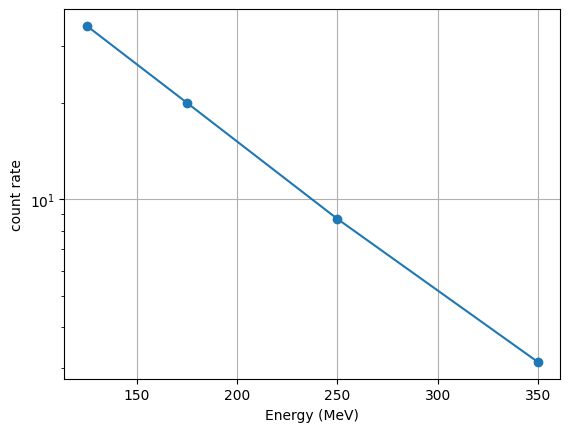

In [116]:
plt.plot(IRENE8_450_protons_differential_single_orbit[IRENE8_450_protons_differential_single_orbit.index == index_for_SAA_max].columns[2:],
        IRENE8_450_protons_differential_single_orbit[IRENE8_450_protons_differential_single_orbit.index == index_for_SAA_max].values[0][2:],marker="o")
plt.yscale("log")
plt.xlabel("Energy (MeV)")
plt.ylabel("count rate")
plt.grid(True)

In [117]:
IRENE8_450_protons_differential_single_orbit[IRENE8_450_protons_differential_single_orbit.index == 825]

,Latitude_deg,Longitude_deg,125.0,175.0,250.0,350.0
825,-19.81355,328.124158,36.086,21.116,9.3537,3.4778


In [118]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

94.4958850347753+/-12.000989400411864

In [119]:
test_single_IRENE8_450_protons_orbital_run_slight_short.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

6.134677424337918+/-2.7435111481705814

In [120]:
3 * test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

45.7238153394074+/-14.459139978547231

In [121]:
3 * test_single_IRENE8_450_protons_orbital_run_slight_short.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.0+/-3.6808064546027506

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


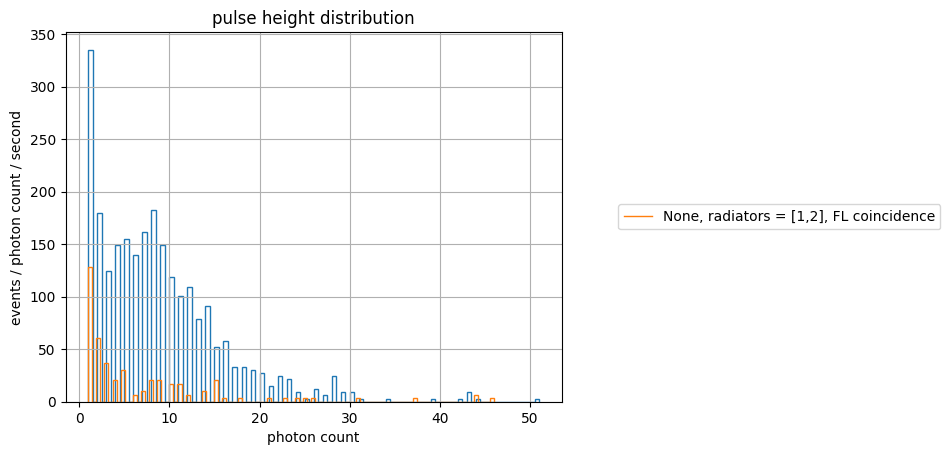

In [122]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

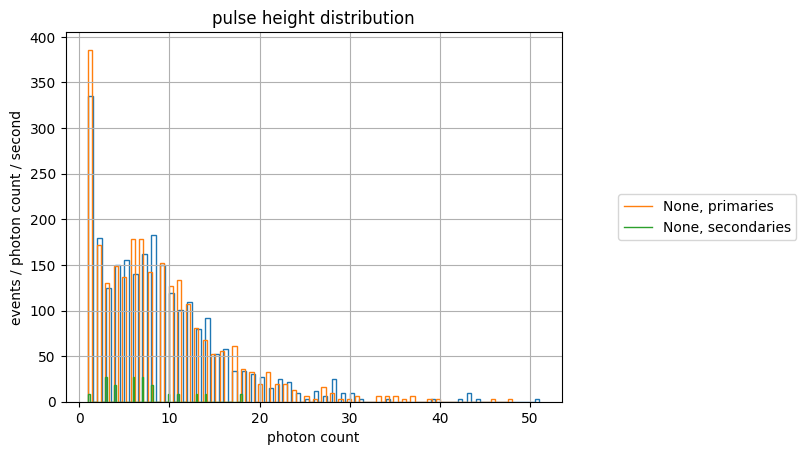

In [123]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.plot_pulse_height_distribution()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution()

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:213: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


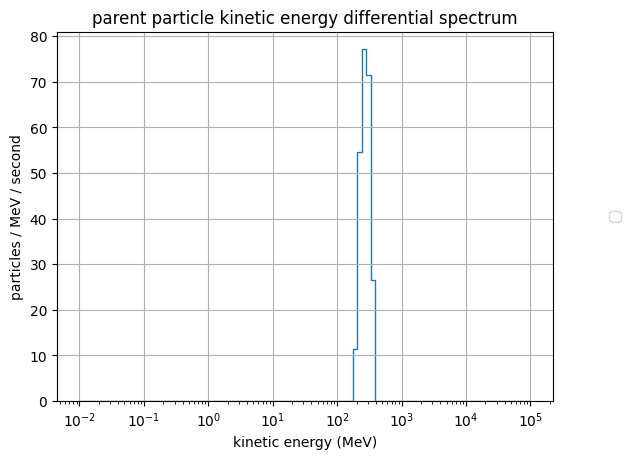

In [124]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_differential_primary_spectra()

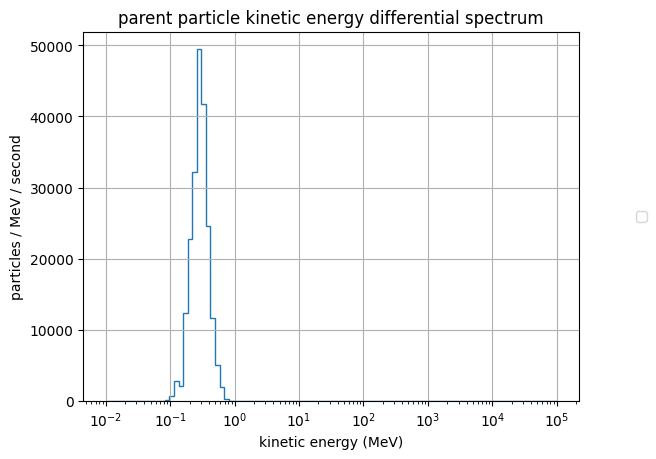

In [125]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].plot_differential_primary_spectra()

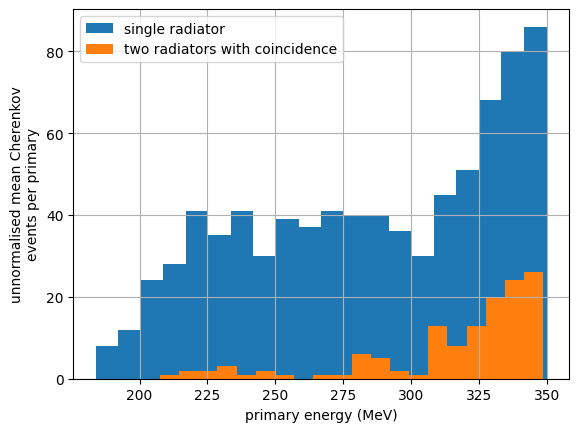

In [126]:
plt.hist(np.unique(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.kinetic_energies_series),
         bins=20,label="single radiator")
plt.hist(np.unique(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.kinetic_energies_series),
         bins=20,label="two radiators with coincidence")

plt.xlabel("primary energy (MeV)")
plt.ylabel("unnormalised mean Cherenkov\nevents per primary")
plt.grid(True)

plt.legend()

save_figure_for_paper("delta_proton_spectra")

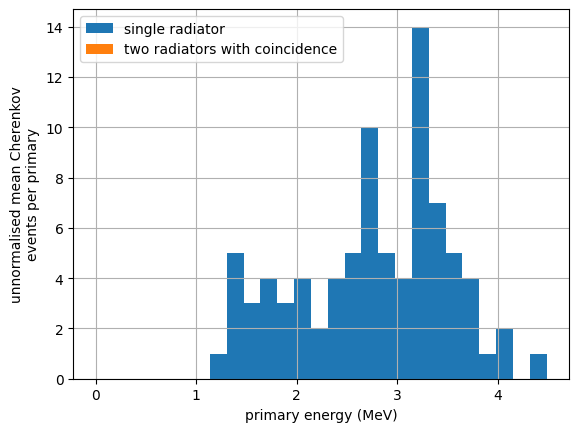

In [127]:
plt.hist(np.unique(test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.kinetic_energies_series),
         bins=20,label="single radiator")
plt.hist(np.unique(test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.kinetic_energies_series),
         bins=20,label="two radiators with coincidence")

plt.xlabel("primary energy (MeV)")
plt.ylabel("unnormalised mean Cherenkov\nevents per primary")
plt.grid(True)

plt.legend()

In [128]:
proton_test_DF_1 = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].DF_of_output_hits
proton_test_DF_1_PR = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.hits['FL1_tuple_fluence;1_PR']
proton_test_DF_1_RA = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].DF_of_output_hits
proton_test_DF_1

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
12,300,-22,0.000005,334.726959,0.000005,228.268372,0.065662
13,300,-22,0.000006,334.726959,0.000006,220.950409,0.048664
14,300,-22,0.000004,334.726959,0.000004,276.268982,0.177158
15,300,-22,0.000006,334.726959,0.000006,211.698669,0.027174
16,300,-22,0.000006,334.726959,0.000006,212.064468,0.028023
...,...,...,...,...,...,...,...
55441,99563,-22,0.000002,303.594574,0.000002,667.565491,0.302123
55442,99563,-22,0.000003,303.594574,0.000003,426.997498,0.586147
55447,99579,-22,0.000006,328.802368,0.000006,221.004715,0.048790
55448,99579,-22,0.000006,328.802368,0.000006,205.878799,0.013655


In [129]:
proton_test_DF_2 = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL2_tuple_fluence;1_CK'].DF_of_output_hits
proton_test_DF_2_PR = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.hits['FL2_tuple_fluence;1_PR']
proton_test_DF_2_RA = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA2_tuple_interaction;1'].DF_of_output_hits
proton_test_DF_2

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
8,799,-22,0.000005,304.001312,0.000005,245.593277,0.105904
9,799,-22,0.000004,304.001312,0.000004,340.792328,0.467907
10,799,-22,0.000005,304.001312,0.000005,230.407608,0.070631
11,799,-22,0.000003,304.001312,0.000003,361.936737,0.512692
12,799,-22,0.000005,304.001312,0.000005,246.908066,0.108958
...,...,...,...,...,...,...,...
56065,99563,-22,0.000005,303.594574,0.000005,233.986099,0.078943
56066,99563,-22,0.000004,303.594574,0.000004,311.018127,0.436602
56081,99614,-22,0.000006,314.294983,0.000006,202.185913,0.005077
56082,99614,-22,0.000006,314.294983,0.000006,203.714111,0.008627


In [130]:
proton_test_DF_coincidence = test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].DF_of_output_hits
proton_test_DF_coincidence

,event_id,particle_id_x,kinetic_energy,primary_kinetic_energy_x,total_energy,wavelength_nm,Si_detection_probability,particle_id_y,primary_kinetic_energy_y,primarymomx,primarymomy,primarymomz,phi,theta,particle_id,primary_kinetic_energy
0,17307,-22,0.000006,318.099091,0.000006,204.740021,0.011010,2212,318.099091,359.575165,-651.095947,380.649139,-61.089825,62.897938,-22,318.099091
1,17307,-22,0.000006,318.099091,0.000006,202.942322,0.006834,2212,318.099091,359.575165,-651.095947,380.649139,-61.089825,62.897938,-22,318.099091
2,21067,-22,0.000005,332.734985,0.000005,233.295975,0.077340,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745,-22,332.734985
3,21067,-22,0.000006,332.734985,0.000006,210.985153,0.025516,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745,-22,332.734985
4,21067,-22,0.000006,332.734985,0.000006,212.377350,0.028750,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745,-22,332.734985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4921,99563,-22,0.000003,303.594574,0.000003,448.454041,0.555623,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574
4922,99563,-22,0.000003,303.594574,0.000003,404.904724,0.598110,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574
4923,99563,-22,0.000004,303.594574,0.000004,287.199890,0.230748,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574
4924,99563,-22,0.000002,303.594574,0.000002,667.565491,0.302123,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574


In [131]:
proton_test_DF_1.head()

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
12,300,-22,0.000005,334.726959,0.000005,228.268372,0.065662
13,300,-22,0.000006,334.726959,0.000006,220.950409,0.048664
14,300,-22,0.000004,334.726959,0.000004,276.268982,0.177158
15,300,-22,0.000006,334.726959,0.000006,211.698669,0.027174
16,300,-22,0.000006,334.726959,0.000006,212.064468,0.028023


In [132]:
proton_test_DF_2.head()

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
8,799,-22,0.000005,304.001312,0.000005,245.593277,0.105904
9,799,-22,0.000004,304.001312,0.000004,340.792328,0.467907
10,799,-22,0.000005,304.001312,0.000005,230.407608,0.070631
11,799,-22,0.000003,304.001312,0.000003,361.936737,0.512692
12,799,-22,0.000005,304.001312,0.000005,246.908066,0.108958


In [133]:
proton_test_DF_1[proton_test_DF_1["event_id"].isin(proton_test_DF_2["event_id"])]["event_id"].unique()

array([17307, 21067, 32879, 32954, 32986, 36398, 47045, 79964, 80158,
       85988,  4201, 23825, 31116, 31141, 34075, 37393, 67854, 80084,
       84607, 88992, 93321, 93371,  1918,  5453,  5488,  5500, 25155,
       25280, 25444, 43403, 77125, 86198, 87509, 87558, 93635,   165,
       21827, 24919, 35435, 36631, 43080, 54699, 54700, 62073, 69632,
       74140, 77473, 82077, 82365, 85252, 97402,  2083, 12674, 14088,
       36113, 44687, 44708, 53342, 55233, 59683, 65540, 66244, 69052,
       70457, 79243, 82630, 94341, 94342, 95838, 97491, 97493,  8244,
       12735, 12792, 14224, 14252, 26220, 33553, 47475, 47487, 51692,
       69982, 69985, 83605, 93021, 96295, 96329,  5335,  6942,  8516,
        8942, 26267, 31589, 35985, 37462, 42085, 43685, 43733, 43742,
       49825, 57289, 60199, 60223, 73727, 75354, 81312, 81395, 81540,
       85863, 94884, 92066, 93495, 96588, 99200, 96808,  3377, 12194,
       13994, 30231, 31750, 33326, 51056, 51077, 52440, 68676, 78312,
       79638, 96780,

In [134]:
len(proton_test_DF_coincidence["event_id"].unique())

213

In [135]:
len(proton_test_DF_1["event_id"].unique())

1141

In [136]:
proton_test_DF_2[proton_test_DF_2["event_id"] == 33973]

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
36116,33973,-22,0.000006,313.11084,0.000006,206.544006,0.015200
36117,33973,-22,0.000006,313.11084,0.000006,210.872116,0.025254


In [137]:
proton_test_DF_2_RA[proton_test_DF_2_RA["event_id"] == 33973]

,event_id,particle_id,kinetic_energy,total_energy,primary_kinetic_energy,wavelength_nm,Si_detection_probability
29300,33973,-22,0.000006,0.000006,299.494202,210.872116,0.025254
29301,33973,-22,0.000006,0.000006,299.494202,206.544006,0.015200


In [138]:
proton_test_DF_2_PR[proton_test_DF_2_PR["event_id"] == 33973]

,event_id,particle_id,primary_kinetic_energy,primarymomx,primarymomy,primarymomz,phi,theta
36114,33973,2212,313.11084,-552.808838,-20.16408,-616.117249,-177.911011,138.081131


In [139]:
proton_test_DF_1[proton_test_DF_1["event_id"] == 33973]

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
35835,33973,-22,0.000006,313.11084,0.000006,207.367538,0.017113
35836,33973,-22,0.000006,313.11084,0.000006,214.596664,0.033905
35837,33973,-22,0.000005,313.11084,0.000005,227.251831,0.063301
35838,33973,-22,0.000006,313.11084,0.000006,203.531631,0.008203


In [140]:
proton_test_DF_1_RA[proton_test_DF_1_RA["event_id"] == 33973]

,event_id,particle_id,kinetic_energy,total_energy,primary_kinetic_energy,wavelength_nm,Si_detection_probability
28586,33973,-22,NaN,0.000006,303.445679,203.531631,0.008203
28587,33973,-22,NaN,0.000005,303.445679,227.251831,0.063301
28588,33973,-22,NaN,0.000006,303.445679,214.596664,0.033905
28589,33973,-22,0.000006,0.000006,303.445679,207.367538,0.017113


In [141]:
proton_test_DF_1[proton_test_DF_1["event_id"].isin(proton_test_DF_2["event_id"])]

,event_id,particle_id,kinetic_energy,primary_kinetic_energy,total_energy,wavelength_nm,Si_detection_probability
531,17307,-22,0.000006,318.099091,0.000006,204.740021,0.011010
532,17307,-22,0.000006,318.099091,0.000006,202.942322,0.006834
842,21067,-22,0.000005,332.734985,0.000005,233.295975,0.077340
843,21067,-22,0.000006,332.734985,0.000006,210.985153,0.025516
844,21067,-22,0.000006,332.734985,0.000006,212.377350,0.028750
...,...,...,...,...,...,...,...
55438,99563,-22,0.000003,303.594574,0.000003,448.454041,0.555623
55439,99563,-22,0.000003,303.594574,0.000003,404.904724,0.598110
55440,99563,-22,0.000004,303.594574,0.000004,287.199890,0.230748
55441,99563,-22,0.000002,303.594574,0.000002,667.565491,0.302123


In [142]:
pd.merge(proton_test_DF_1[proton_test_DF_1["event_id"].isin(proton_test_DF_2["event_id"])],proton_test_DF_1_PR, on='event_id',how="inner")

,event_id,particle_id_x,kinetic_energy,primary_kinetic_energy_x,total_energy,wavelength_nm,Si_detection_probability,particle_id_y,primary_kinetic_energy_y,primarymomx,primarymomy,primarymomz,phi,theta
0,17307,-22,0.000006,318.099091,0.000006,204.740021,0.011010,2212,318.099091,359.575165,-651.095947,380.649139,-61.089825,62.897938
1,17307,-22,0.000006,318.099091,0.000006,202.942322,0.006834,2212,318.099091,359.575165,-651.095947,380.649139,-61.089825,62.897938
2,21067,-22,0.000005,332.734985,0.000005,233.295975,0.077340,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745
3,21067,-22,0.000006,332.734985,0.000006,210.985153,0.025516,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745
4,21067,-22,0.000006,332.734985,0.000006,212.377350,0.028750,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4921,99563,-22,0.000003,303.594574,0.000003,448.454041,0.555623,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973
4922,99563,-22,0.000003,303.594574,0.000003,404.904724,0.598110,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973
4923,99563,-22,0.000004,303.594574,0.000004,287.199890,0.230748,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973
4924,99563,-22,0.000002,303.594574,0.000002,667.565491,0.302123,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973


In [143]:
proton_test_DF_coincidence.dropna()

,event_id,particle_id_x,kinetic_energy,primary_kinetic_energy_x,total_energy,wavelength_nm,Si_detection_probability,particle_id_y,primary_kinetic_energy_y,primarymomx,primarymomy,primarymomz,phi,theta,particle_id,primary_kinetic_energy
0,17307,-22,0.000006,318.099091,0.000006,204.740021,0.011010,2212,318.099091,359.575165,-651.095947,380.649139,-61.089825,62.897938,-22,318.099091
1,17307,-22,0.000006,318.099091,0.000006,202.942322,0.006834,2212,318.099091,359.575165,-651.095947,380.649139,-61.089825,62.897938,-22,318.099091
2,21067,-22,0.000005,332.734985,0.000005,233.295975,0.077340,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745,-22,332.734985
3,21067,-22,0.000006,332.734985,0.000006,210.985153,0.025516,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745,-22,332.734985
4,21067,-22,0.000006,332.734985,0.000006,212.377350,0.028750,2212,332.734985,-64.037064,-720.447449,-460.390228,-95.079391,122.477745,-22,332.734985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4921,99563,-22,0.000003,303.594574,0.000003,448.454041,0.555623,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574
4922,99563,-22,0.000003,303.594574,0.000003,404.904724,0.598110,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574
4923,99563,-22,0.000004,303.594574,0.000004,287.199890,0.230748,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574
4924,99563,-22,0.000002,303.594574,0.000002,667.565491,0.302123,2212,303.594574,350.607635,-48.864216,732.505859,-7.934209,25.792973,-22,303.594574


In [144]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].DF_of_output_hits

,event_id,particle_id,kinetic_energy,total_energy,primary_kinetic_energy,wavelength_nm,Si_detection_probability
1,1918,-22,0.000006,0.000006,301.337158,204.029755,0.009360
2,1918,-22,NaN,0.000006,301.337158,210.566910,0.024545
3,1918,-22,NaN,0.000006,301.337158,207.873886,0.018290
10,5453,-22,NaN,0.000006,312.763062,201.572449,0.003652
11,5453,-22,NaN,0.000006,312.763062,215.663971,0.036384
...,...,...,...,...,...,...,...
43948,99563,-22,NaN,0.000003,0.241152,426.997498,0.586147
43949,99563,-22,NaN,0.000002,0.241152,667.565491,0.302123
43954,99579,-22,NaN,0.000005,325.251160,275.484589,0.175336
43955,99579,-22,NaN,0.000006,325.251160,205.878799,0.013655


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


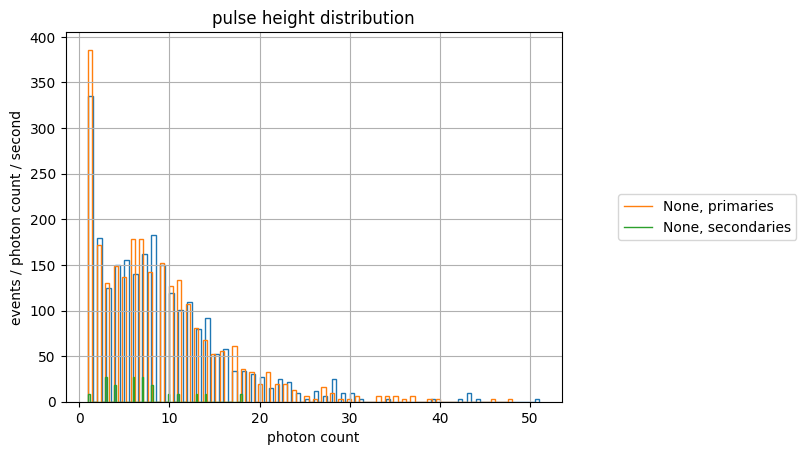

In [145]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.plot_pulse_height_distribution()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution()

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:233: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


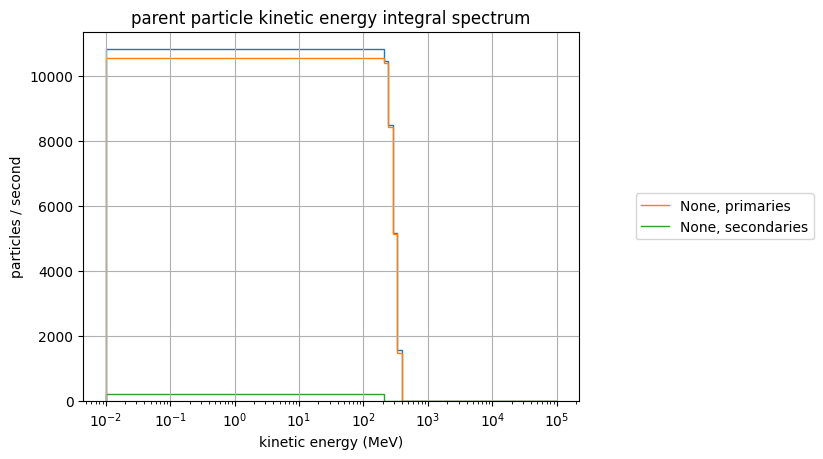

In [146]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_integral_primary_spectra()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.plot_integral_primary_spectra()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].secondary_particle_Cherenkov_tuple.plot_integral_primary_spectra()

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:213: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


(100, 1000)

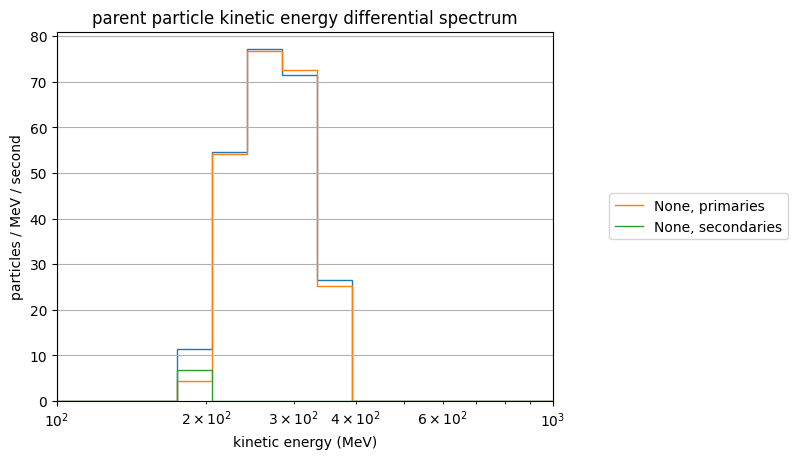

In [147]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_differential_primary_spectra()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].secondary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
plt.xlim([100,1000])

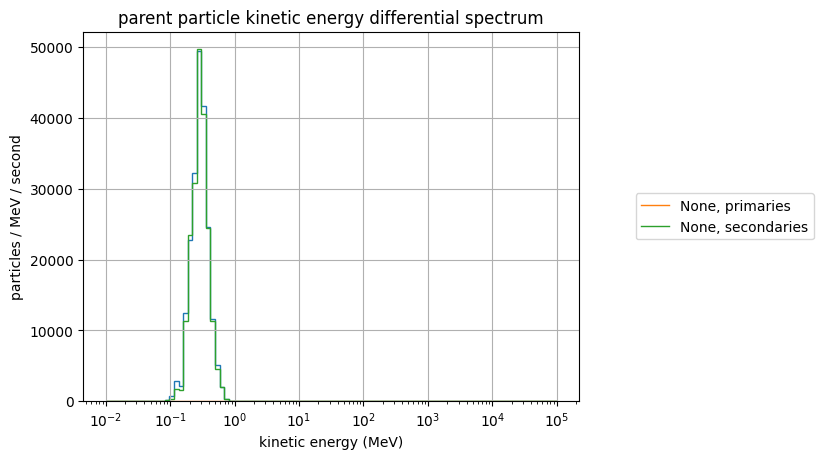

In [148]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].plot_differential_primary_spectra()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].primary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.plot_differential_primary_spectra()

(0.01, 10)

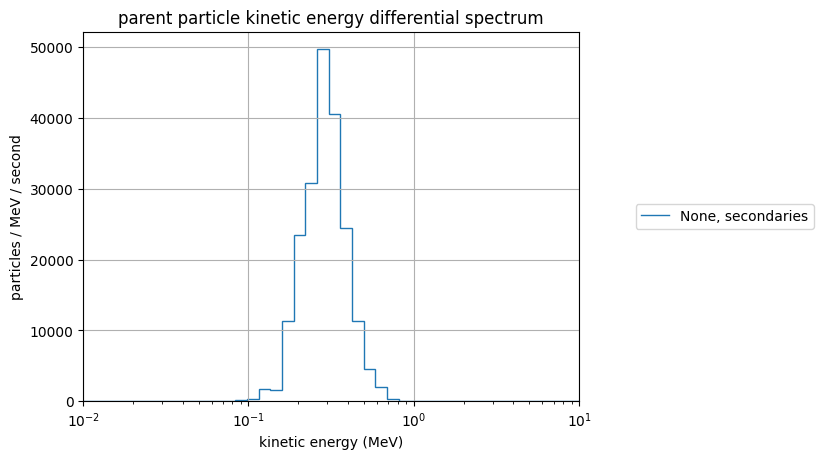

In [149]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
plt.xlim([0.01,10])

In [150]:
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.parent_particle_quantile(0.5))
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.parent_particle_quantile(0.5))
#test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
#test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].secondary_particle_Cherenkov_tuple.plot_differential_primary_spectra()
#plt.xlim([100,1000])

281.9729919433594
283.6200866699219


In [151]:
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.parent_particle_quantile(0.5))
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].primary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.parent_particle_quantile(0.5))
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.parent_particle_quantile(0.5))

0.3208107650279999
331.9664611816406
0.3094533383846283


In [152]:
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.parent_particle_quantile(0.75))
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.parent_particle_quantile(0.5))
print(test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.parent_particle_quantile(0.25))

0.3762587010860443
0.3094533383846283
0.26154282689094543


In [153]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].DF_of_output_hits["event_id"].sort_values().unique()

array([  165,   202,   300, ..., 99579, 99778, 99984],
      shape=(1141,), dtype=int32)

In [154]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL2_tuple_fluence;1_CK'].DF_of_output_hits["event_id"].sort_values().unique()

array([   89,   126,   127, ..., 99614, 99624, 99716],
      shape=(1203,), dtype=int32)

In [155]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].DF_of_output_hits["event_id"].sort_values().unique()

array([  165,   202,   300, ..., 99579, 99778, 99984],
      shape=(1140,), dtype=int32)

In [156]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['RA2_tuple_interaction;1'].DF_of_output_hits["event_id"].sort_values().unique()

array([   89,   126,   127, ..., 99614, 99624, 99716],
      shape=(1203,), dtype=int32)

In [157]:
test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

94.4958850347753+/-12.000989400411864

In [158]:
3 * test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

45.7238153394074+/-14.459139978547231

In [159]:
test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

208.69579128217867+/-41.73915825643574

In [160]:
3 * test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.0+/-25.043494953861444

In [161]:
test_single_IRENE8_450_electrons_orbital_run_slight_short.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

166.95513043107167+/-118.0551048816953

In [162]:
3 * test_single_IRENE8_450_electrons_orbital_run_slight_short.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.0+/-250.4326956466075

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:198: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))


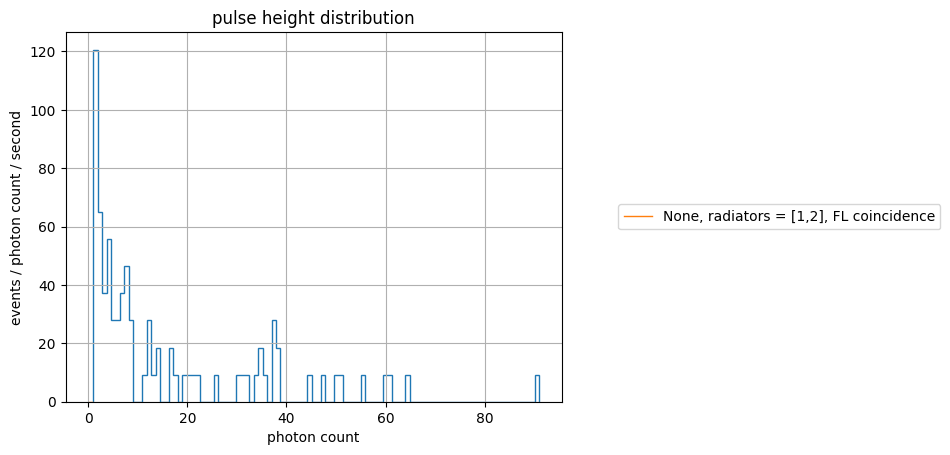

In [163]:
test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

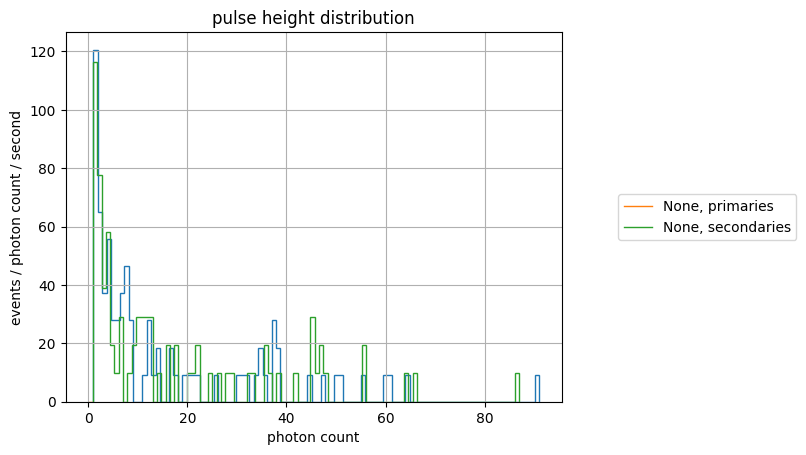

In [164]:
test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].primary_particle_Cherenkov_tuple.plot_pulse_height_distribution()
test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution()

## Running for selected trapped electron regions

In [165]:
IRENE8_450_electrons_differential_shortened_single_orbit[IRENE8_450_electrons_differential_shortened_single_orbit.index == 843]

,Latitude_deg,Longitude_deg,1.125,1.375,1.625,1.875,2.125,2.375,2.625,2.875,...,3.625,3.875,4.125,4.375,4.625,4.875,5.25,5.75,6.25,6.75
843,-79.1385,323.613636,11178.0,5593.6,2407.4,1359.56,866.44,436.8,169.724,104.668,...,29.672,17.1352,10.8192,12.5496,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [167]:
high_stats_test_single_IRENE8_450_electrons_orbital_run = orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit[IRENE8_450_electrons_differential_shortened_single_orbit.index == 843], 
                                               particle_species="e-",
                                               number_of_particles_to_simulate=100_000_000,
                                               label="AE8 electrons",
                                               threshold_photon_value=20.0,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a5735bb0>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=100000000, number_of_radiators=2, save_DF_of_output_hits=False)


0it [00:04, ?it/s]


KeyError: 'FL1_tuple_fluence;1_CK'

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.estimated_number_of_incoming_particles

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].number_of_events_simulated

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843].outputted_tuple.number_of_events_simulated

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843]

In [ ]:
high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[843].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].plot_pulse_height_distribution()

In [168]:
SAA_max_high_stats_test_single_IRENE8_450_electrons_orbital_run = orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit[IRENE8_450_electrons_differential_shortened_single_orbit.index == index_for_SAA_max], 
                                               particle_species="e-",
                                               number_of_particles_to_simulate=100_000_000, #100_000_000,
                                               label="AE8 electrons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a5b36f90>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=100000000, number_of_radiators=2, save_DF_of_output_hits=False)


0it [10:10, ?it/s]


KeyError: 'FL1_tuple_fluence;1_CK'

In [ ]:
SAA_max_high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

In [ ]:
horns_high_stats_test_single_IRENE8_450_electrons_orbital_run = orbital_run(IRENE8_450_electrons_differential_shortened_single_orbit[IRENE8_450_electrons_differential_shortened_single_orbit.index == index_for_horns_max], 
                                               particle_species="e-",
                                               number_of_particles_to_simulate=10_000_000, #100_000_000,
                                               label="AE8 electrons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

In [ ]:
horns_max_elec_coincidence_counts = horns_high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_horns_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)
horns_max_elec_coincidence_counts

## Running for selected trapped proton regions

In [169]:
IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == 843]

,Latitude_deg,Longitude_deg,0.125,0.175,0.25,0.35,0.45,0.55,0.65,0.85,...,25.0,35.0,45.0,55.0,65.0,85.0,125.0,175.0,250.0,350.0
843,-79.1385,323.613636,13188.2,5441.6,1622.53,244.996,43.574,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [170]:
high_stats_test_single_IRENE8_450_protons_orbital_run = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == 843], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=1_000_000,
                                               label="AP8 protons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a5d88230>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=1000000, number_of_radiators=2, save_DF_of_output_hits=False)
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengt

/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse

calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
_____________________wrapper_gras_Cherenkov_runner_from_objects - 177.0s, 2.9min


In [171]:
high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[843].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

0.0+/-0.042254842164198295

In [172]:
IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == 843]

,Latitude_deg,Longitude_deg,0.125,0.175,0.25,0.35,0.45,0.55,0.65,0.85,...,25.0,35.0,45.0,55.0,65.0,85.0,125.0,175.0,250.0,350.0
843,-79.1385,323.613636,13188.2,5441.6,1622.53,244.996,43.574,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [173]:
index_for_SAA_max

826

In [174]:
SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == index_for_SAA_max], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=1_000_000,
                                               label="AP8 protons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a5f64f80>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=1000000, number_of_radiators=2, save_DF_of_output_hits=False)


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


1it [02:55, 175.99s/it]

_____________________wrapper_gras_Cherenkov_runner_from_objects - 176.0s, 2.9min


In [175]:
SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

100.54338614390714+/-9.81202978723315

In [176]:
SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

14.36334087770102+/-3.708598667682418

In [177]:
test_orbital_run_1 = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == index_for_SAA_max], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=10_000,
                                               label="AP8 protons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

test_orbital_run_2 = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == index_for_SAA_max], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=10_001,
                                               label="AP8 protons 2",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

test_orbital_run_3 = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == index_for_SAA_max], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=10_002,
                                               label="AP8 protons 2",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]

________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a6108d40>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=10000, number_of_radiators=2, save_DF_of_output_hits=False)


/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

...

________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a6e792e0>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=10002, number_of_radiators=2, save_DF_of_output_hits=False)


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:328: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["wavelength_nm"] = self.get_photon_wavelength_nm(generated_photons_DF["total_energy"]*1e6)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:330: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  generated_photons_DF["Si_detection_probability"] = photodetector

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


1it [00:04,  4.64s/it]

_______________________wrapper_gras_Cherenkov_runner_from_objects - 4.6s, 0.1min


In [178]:
test_orbital_run_1.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=0.0)

1436.3340877701019+/-370.8598667682418

In [179]:
test_orbital_run_2.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=0.0)

1627.6825312196604+/-394.7710000700809

In [180]:
test_orbital_run_3.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=0.0)

1627.5197955136796+/-394.7315308639151

In [184]:
horns_max_high_stats_test_single_IRENE8_450_protons_orbital_run_dict = {}
for index, n_particles_to_simulate in enumerate(range(10_000_000,10_000_010)):
    horns_max_high_stats_test_single_IRENE8_450_protons_orbital_run_dict[index] = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == index_for_horns_max], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=n_particles_to_simulate,
                                               label="AP8 protons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a4ce80e0>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=10000000, number_of_radiators=2, save_DF_of_output_hits=False)


0it [00:02, ?it/s]


KeyError: 'FL1_tuple_fluence;1_CK'

In [182]:
pd.Series(horns_max_high_stats_test_single_IRENE8_450_protons_orbital_run_dict).apply(lambda x:x.run_dict[index_for_horns_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0))

Series([], dtype: object)

In [185]:
horns_max_high_stats_test_single_IRENE8_450_protons_orbital_run = orbital_run(IRENE8_450_protons_original_differential_single_orbit[IRENE8_450_protons_original_differential_single_orbit.index == index_for_horns_max], 
                                               particle_species="proton",
                                               number_of_particles_to_simulate=10_000_000,
                                               label="AP8 protons",
                                               threshold_photon_value=20.0,
                                               ignore_coincidence_horns_regions=False,
                                               save_DF_of_output_hits = False)

0it [00:00, ?it/s]

/tmp/ipykernel_147622/1299880705.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  max_particles_per_s = np.trapz(spectrum_row[2:].values, spectrum_row[2:].index)


________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a4cd9880>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, Cherenkov_run_label=None, number_of_particles=10000000, number_of_radiators=2, save_DF_of_output_hits=False)


0it [05:07, ?it/s]


KeyError: 'FL1_tuple_fluence;1_CK'

In [ ]:
horns_max_prot_coincidence_counts = horns_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_horns_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0) / 10
horns_max_prot_coincidence_counts

In [ ]:
horns_max_prot_coincidence_counts + horns_max_elec_coincidence_counts

In [ ]:
horns_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_horns_max].outputted_tuple.coincidence_tuple_dictionary[1][2]["FL"].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value=20.0)

## Running across multiple rigidities

running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...
running MAGNETOCOSMICS to acquire asymptotic directions...


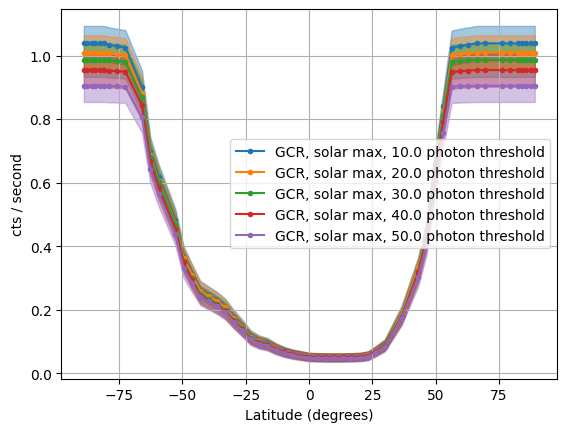

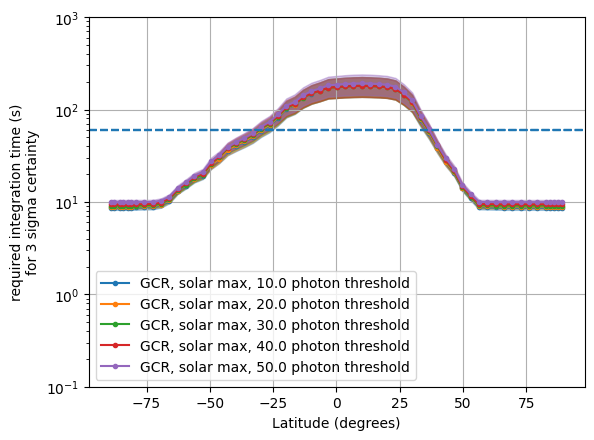

: 

In [ ]:
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    multi_rigidity_run(SRT.get_GCR_Cherenkov_run_rigidity_cut_off,
                       datetime_to_use=SRT.datetime_for_GCR_solar_max, 
                       input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]], 
                       label = f"GCR, solar max, {photon_threshold} photon threshold", 
                       number_of_radiators=2, 
                       threshold_photon_value=photon_threshold).plot_count_rates_against_longitude_0()
plt.legend()

plt.figure()
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    multi_rigidity_run(SRT.get_GCR_Cherenkov_run_rigidity_cut_off,
                       datetime_to_use=SRT.datetime_for_GCR_solar_max,
                       input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                       label = f"GCR, solar max, {photon_threshold} photon threshold", 
                       number_of_radiators=2,
                       threshold_photon_value=photon_threshold).plot_int_time_array_vs_longitude_0()
plt.legend()

In [ ]:
GLE21_spectrum = SRT.particle_spectrum(particle_species=SRT.particle("proton"),
                                        spectrum_file_path="GLE21spectrum_multipliedby1.csv",
                                        incoming_particles_per_s_per_cm2=SRT.GLE21_integral_count_rate)

GLE05_spectrum = SRT.particle_spectrum(particle_species=SRT.particle("proton"),
                                        spectrum_file_path="GLE05spectrum_multipliedby1.csv",
                                        incoming_particles_per_s_per_cm2=SRT.GLE05_integral_count_rate)

multi_rigidity_GLE21 = multi_rigidity_run(SRT.get_GLE_Cherenkov_run_rigidity_cut_off,
                                          label="GLE21 protons",
                                          input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                                          number_of_radiators=2,
                                          array_of_rigidities_GV=default_rigidities,
                                          GLE_spec=GLE21_spectrum,
                                          threshold_photon_value=20.0,
                                          number_of_particles=1_000_000)

multi_rigidity_GLE05 = multi_rigidity_run(SRT.get_GLE_Cherenkov_run_rigidity_cut_off,
                                          label="GLE05 protons",
                                          input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                                          number_of_radiators=2,
                                          array_of_rigidities_GV=default_rigidities,
                                          GLE_spec=GLE05_spectrum,
                                          threshold_photon_value=20.0,
                                          number_of_particles=1_000_000)

________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a5f661b0>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, number_of_particles=1000000, threshold_primary_energy=np.float64(2205.031032796676), number_of_radiators=2)
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})


successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})


successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})


successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse

successfully read in data...
assigned wavelengths and detector detection probabilities...
calculated pulse height values.
_____________________wrapper_gras_Cherenkov_runner_from_objects - 196.2s, 3.3min
________________________________________________________________________________
[Memory] Calling spectra_running_tools.wrapper_gras_Cherenkov_runner_from_objects...
wrapper_gras_Cherenkov_runner_from_objects(<spectra_running_tools.particle_spectrum object at 0x7f12a5f661b0>, <spectra_running_tools.spacecraft_shielding_geometry object at 0x7f12be53a990>, number_of_particles=1000000, threshold_primary_energy=np.float64(3170.298771602413), number_of_radiators=2)


/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:157: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ones_at_zero_values = self.pulse_height_values.applymap(lambda x: 1 if x==0 else 0)
/home/xisacross/programming/HEPI/WP4100_simulations/testing_modifications/running_from_Python/Cherenkov_run_tuple.py:260: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  self.pulse_height_values = generated_photons_DF.groupby("event_id",sort=False).agg({"Si_detection_probability":sum})


In [ ]:
multi_rigidity_GLE21.plot_count_rates_against_longitude_0()
plt.figure()
multi_rigidity_GLE21.plot_int_time_array_vs_longitude_0()

In [ ]:
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    multi_rigidity_run(SRT.get_GLE_Cherenkov_run_rigidity_cut_off,
                                          label=f"GLE21 protons, {photon_threshold} photon threshold",
                                          input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                                          number_of_radiators=2,
                                          array_of_rigidities_GV=default_rigidities,
                                          GLE_spec=GLE21_spectrum,
                                          threshold_photon_value=photon_threshold,
                                          number_of_particles=1_000_000).plot_count_rates_against_longitude_0()
plt.legend()

plt.figure()
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    multi_rigidity_run(SRT.get_GLE_Cherenkov_run_rigidity_cut_off,
                                          label=f"GLE21 protons, {photon_threshold} photon threshold",
                                          input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                                          number_of_radiators=2,
                                          array_of_rigidities_GV=default_rigidities,
                                          GLE_spec=GLE21_spectrum,
                                          threshold_photon_value=photon_threshold,
                                          number_of_particles=1_000_000).plot_int_time_array_vs_longitude_0()
plt.legend()

In [ ]:
multi_rigidity_GLE05.plot_count_rates_against_longitude_0()
plt.figure()
multi_rigidity_GLE05.plot_int_time_array_vs_longitude_0()
plt.legend()

In [ ]:
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    multi_rigidity_run(SRT.get_GLE_Cherenkov_run_rigidity_cut_off,
                                          label=f"GLE05 protons, {photon_threshold} photon threshold",
                                          input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                                          number_of_radiators=2,
                                          array_of_rigidities_GV=default_rigidities,
                                          GLE_spec=GLE05_spectrum,
                                          threshold_photon_value=photon_threshold,
                                          number_of_particles=1_000_000).plot_count_rates_against_longitude_0()
plt.legend()

plt.figure()
for photon_threshold in [10.0,20.0,30.0,40.0,50.0]:
    multi_rigidity_run(SRT.get_GLE_Cherenkov_run_rigidity_cut_off,
                                          label=f"GLE05 protons, {photon_threshold} photon threshold",
                                          input_DF_of_coords=IRENE8_450_protons_differential_single_orbit[["Latitude_deg","Longitude_deg"]],
                                          number_of_radiators=2,
                                          array_of_rigidities_GV=default_rigidities,
                                          GLE_spec=GLE05_spectrum,
                                          threshold_photon_value=photon_threshold,
                                          number_of_particles=1_000_000).plot_int_time_array_vs_longitude_0()
plt.legend()

In [ ]:
spacecraft_coords_DF

In [ ]:
def soft_divide(numerator, denominator):

    try:
        return numerator / denominator
    except ZeroDivisionError:
        return ufloat(0.0,0.0)

In [ ]:
def calculate_int_time_functional(x_value, signal_flux_func, list_of_background_flux_functions, sigma=3):

    signal_flux = signal_flux_func(x_value)
    signal_flux_modified = np.array([(signal if signal.n != 0.0 else ufloat(np.nan,np.nan)) for signal in signal_flux])

    numerator = (signal_flux_modified + sum([background_flux_func(x_value) for background_flux_func in list_of_background_flux_functions]))

    return (sigma**2) * numerator / (signal_flux_modified**2) 

In [ ]:
def plot_world_map():
    worldmap = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

    # Creating axes and plotting world map
    fig, ax = plt.subplots(figsize=(12, 6))
    worldmap.plot(color="lightgrey", ax=ax)

In [ ]:
def long_east_to_west(longitude_east):

    if longitude_east > 180:
        output_longitude = longitude_east - 360.0
    else:
        output_longitude = longitude_east

    return output_longitude

In [ ]:
class full_orbit_background():

    def __init__(self, 
                 DF_of_coordinates:pd.DataFrame, 
                 list_of_multi_rigidity_runs = [],
                 list_of_orbit_background_runs = [],
                 label=None,
                 datetime_for_rigidities = SRT.datetime_for_GCR_solar_max):

        self.DF_of_coordinates = DF_of_coordinates
        self.DF_of_coordinates["orbital_step"] = self.DF_of_coordinates.index
        self.list_of_multi_rigidity_runs = list_of_multi_rigidity_runs
        self.list_of_orbit_background_runs = list_of_orbit_background_runs
        self.label = label

        self.rigidities_for_coordinates = AsympDirsTools.get_magcos_vcutoffs(array_of_lats_and_longs = DF_of_coordinates[["Latitude_deg","Longitude_deg"]].values,
                                            dateAndTime=datetime_for_rigidities,cache=True)
        self.rigidities_for_coordinates = self.rigidities_for_coordinates[
            #np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != -81.194370) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != 72.753770) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != -56.147930) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != -69.295260) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != 39.842640) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != 42.992710) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != -3.229399) &
            np.array(self.rigidities_for_coordinates.reset_index()["initialLatitude"] != 33.233800)]  
        self.rigidities_for_coordinates.iloc[5] = self.rigidities_for_coordinates.iloc[4]

        self.rig_interp_list = []
        for multi_rigidity_run in list_of_multi_rigidity_runs:
            count_rate_DF = pd.DataFrame(self.rigidities_for_coordinates["Reffective"].copy())
            count_rate_DF["count_rate"] = multi_rigidity_run.rig_interp(count_rate_DF["Reffective"])

            list_of_sub_coordinates = []
            for index, row in count_rate_DF.reset_index().iterrows():
                relevant_coord = self.DF_of_coordinates[self.DF_of_coordinates["Latitude_deg"] == row["initialLatitude"]]
                list_of_sub_coordinates.append(relevant_coord)
            DF_of_sub_coordinates = pd.concat(list_of_sub_coordinates).reset_index()
            count_rate_DF = pd.concat([count_rate_DF.reset_index(),DF_of_sub_coordinates],axis=1).sort_values(by="index")
            count_rate_DF.label = multi_rigidity_run.label

            self.rig_interp_list.append(count_rate_DF)


        self.dict_of_interp_functions = {}
        dict_index = 0
        for interped_rig in self.rig_interp_list:
            self.dict_of_interp_functions[dict_index] = uncertainty_interp1d(x=interped_rig["index"],y=interped_rig["count_rate"])
            self.dict_of_interp_functions[dict_index].label = interped_rig.label
            dict_index += 1

        for orbit_background_run in self.list_of_orbit_background_runs:
            self.dict_of_interp_functions[dict_index] = uncertainty_interp1d(x=orbit_background_run.run_dict_event_counts.index,
                                                            y=orbit_background_run.run_dict_event_counts.values)
            self.dict_of_interp_functions[dict_index].label = orbit_background_run.label
            dict_index += 1

    def plot_cosmic_particles(self, xcol_to_plot_against="orbital_step", indicies=":", error_bar_function=plt.errorbar):

        if indicies == ":":
            rig_interp_list = self.rig_interp_list
        else:
            rig_interp_list = [self.rig_interp_list[indicies]]
        
        for interped_rig in rig_interp_list:
            #interped_rig.plot("index","count_rate",ax=plt.gca())
            error_bar_function(interped_rig[xcol_to_plot_against],
                     interped_rig["count_rate"].apply(lambda x:x.n),
                     interped_rig["count_rate"].apply(lambda x:x.std_dev),
                     label=interped_rig.label)

        plt.xlabel(xcol_to_plot_against)
        plt.ylabel("counts / second")
        plt.legend()

    def plot_count_rates(self, xcol_to_plot_against="orbital_step",error_bar_function=plt.errorbar):

        self.plot_cosmic_particles(xcol_to_plot_against,error_bar_function=error_bar_function)

        for orbit_background_run in self.list_of_orbit_background_runs:
            orbit_background_run.plot_run_dict(xvalues_to_use = self.DF_of_coordinates[xcol_to_plot_against],error_bar_function=error_bar_function)

        plt.xlabel(xcol_to_plot_against)
        plt.ylabel("counts / second")
        plt.legend()

    def plot_cosmic_vs_trapped(self, xcol_to_plot_against="orbital_step",error_bar_function=plt.errorbar):

        self.plot_cosmic_particles(xcol_to_plot_against,error_bar_function=error_bar_function)

        first_sum = True
        for orbit_background_run in self.list_of_orbit_background_runs:
            if first_sum is True:
                total_background_run = orbit_background_run
                first_sum=False
            else:
                total_background_run = total_background_run + orbit_background_run
                
        total_background_run.plot_run_dict(xvalues_to_use = self.DF_of_coordinates[xcol_to_plot_against],error_bar_function=error_bar_function)

        if xcol_to_plot_against is "Latitude_deg":
            plt.xlabel("Latitude (degrees)")
        else:
            plt.xlabel(xcol_to_plot_against)
        plt.ylabel("counts / second")
        plt.legend()

    def plot_int_time(self, signal_index=0, xcol_to_plot_against="orbital_step"):

        signal_interp_function = self.dict_of_interp_functions[signal_index]
        keys_array = np.array(list(self.dict_of_interp_functions.keys()))
        background_indicies = keys_array[keys_array != signal_index]
        background_interp_function_list = [self.dict_of_interp_functions[index] for index in background_indicies]

        # signal_values = signal_interp_function(self.DF_of_coordinates.index)
        # background_values = background_interp_function(self.DF_of_coordinates.index)

        output_int_time_values = calculate_int_time_functional(self.DF_of_coordinates.index, 
                                                               signal_interp_function, 
                                                               background_interp_function_list,
                                                               sigma=3)

        xvals_to_plot_against = self.DF_of_coordinates[xcol_to_plot_against]

        #plt.plot(self.DF_of_coordinates.index, output_int_time_values)
        # plt.errorbar(xvals_to_plot_against, #self.DF_of_coordinates.index,
        #              [time_value.n for time_value in output_int_time_values],
        #              [time_value.std_dev for time_value in output_int_time_values])
        
        fill_between_errorbar(xvals_to_plot_against, #self.DF_of_coordinates.index,
                     [time_value.n for time_value in output_int_time_values],
                     [time_value.std_dev for time_value in output_int_time_values],
                     label=signal_interp_function.label)

        plt.axhline(60,ls="--")
        plt.xlabel(xcol_to_plot_against)
        plt.ylabel("required integration time (s)\nfor 3 sigma certainty")
        plt.ylim([0.1,1000])
        plt.yscale("log")
        plt.grid(True)
        plt.legend()

        #return output_int_time_values

    def plot_spacecraft_trajectory(self):

        plot_world_map()

        self.DF_of_coordinates["Longitude_east_deg"] = self.DF_of_coordinates["Longitude_deg"].apply(long_east_to_west)

        sns.scatterplot(data=self.DF_of_coordinates,x="Longitude_east_deg",y="Latitude_deg")

    def get_count_rate_info(self, signal_index=0):

        print(f"polar count rate is: {self.rig_interp_list[signal_index][self.rig_interp_list[signal_index]['index'] == index_for_polar]['count_rate'].iloc[0]}".replace("+/-","±"))
        print(f"horns count rate is: {self.rig_interp_list[signal_index][self.rig_interp_list[signal_index]['index'] == index_for_horns_max]['count_rate'].iloc[0]}".replace("+/-","±"))
        print(f"SAA count rate is: {self.rig_interp_list[signal_index][self.rig_interp_list[signal_index]['index'] == index_for_SAA_max]['count_rate'].iloc[0]}".replace("+/-","±"))

    
    def get_int_time_info(self, signal_index=0, account_for_background=True):

        signal_interp_function = self.dict_of_interp_functions[signal_index]
        keys_array = np.array(list(self.dict_of_interp_functions.keys()))
        background_indicies = keys_array[keys_array != signal_index]
        if account_for_background==True:
            background_interp_function_list = [self.dict_of_interp_functions[index] for index in background_indicies]
        else:
            background_interp_function_list = [lambda x:0]

        # signal_values = signal_interp_function(self.DF_of_coordinates.index)
        # background_values = background_interp_function(self.DF_of_coordinates.index)

        output_int_time_values = calculate_int_time_functional(self.DF_of_coordinates.index, 
                                                               signal_interp_function, 
                                                               background_interp_function_list,
                                                               sigma=3)

        xvals_to_plot_against = self.DF_of_coordinates["orbital_step"]

        print(f"polar int time is: {output_int_time_values[xvals_to_plot_against == index_for_polar][0]}".replace("+/-","±"))
        print(f"horns int time is: {output_int_time_values[xvals_to_plot_against == index_for_horns_max][0]}".replace("+/-","±"))
        print(f"SAA int time is: {output_int_time_values[xvals_to_plot_against == index_for_SAA_max][0]}".replace("+/-","±"))
        

In [ ]:
default_trajectory_DF = spacecraft_coords_DF.iloc[790:850]
default_trajectory_DF["Minutes"] = (default_trajectory_DF["ModifiedJulianDay"] - default_trajectory_DF["ModifiedJulianDay"].iloc[0]) * (24 * 60)

In [ ]:
GCR_orbit_background = full_orbit_background(default_trajectory_DF,
                                              list_of_multi_rigidity_runs=[GCR_max_multi_rig_run],
                                              list_of_orbit_background_runs=[IRENE8_450_electrons_orbital_run,IRENE8_450_protons_orbital_run],
                                              label="GCR protons, solar max")
GCR_orbit_background.plot_spacecraft_trajectory()
plt.figure()
GCR_orbit_background.plot_count_rates(xcol_to_plot_against="Minutes")
plt.figure()
GCR_orbit_background.plot_count_rates(xcol_to_plot_against="Latitude_deg")#,error_bar_function=fill_between_errorbar)
plt.figure()
GCR_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Minutes")
plt.figure()

GCR_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Latitude_deg")

plt.figure()
GCR_orbit_background.plot_int_time(signal_index=0,xcol_to_plot_against="Minutes")
plt.figure()
GCR_orbit_background.plot_int_time(signal_index=0,xcol_to_plot_against="Latitude_deg")


In [ ]:
GLE21_orbit_background = full_orbit_background(default_trajectory_DF,
                                              list_of_multi_rigidity_runs=[GCR_max_multi_rig_run,multi_rigidity_GLE21],
                                              list_of_orbit_background_runs=[IRENE8_450_electrons_orbital_run,IRENE8_450_protons_orbital_run])
GLE21_orbit_background.plot_spacecraft_trajectory()
plt.figure()
GLE21_orbit_background.plot_count_rates(xcol_to_plot_against="Minutes")
plt.figure()
GLE21_orbit_background.plot_count_rates(xcol_to_plot_against="Latitude_deg",error_bar_function=fill_between_errorbar)
plt.figure()
GLE21_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Minutes")
plt.figure()
GLE21_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Latitude_deg")
plt.figure()
GLE21_orbit_background.plot_int_time(signal_index=1,xcol_to_plot_against="Minutes")
plt.figure()
GLE21_orbit_background.plot_int_time(signal_index=1,xcol_to_plot_against="Latitude_deg")

In [ ]:
GLE05_orbit_background = full_orbit_background(default_trajectory_DF,
                                              list_of_multi_rigidity_runs=[GCR_max_multi_rig_run,multi_rigidity_GLE05],
                                              list_of_orbit_background_runs=[IRENE8_450_electrons_orbital_run,IRENE8_450_protons_orbital_run])

GLE05_orbit_background.plot_spacecraft_trajectory()
plt.xlabel("Longitude (degrees)")
plt.ylabel("Latitude (degrees)")
plt.grid(True)
plt.figure()
GLE05_orbit_background.plot_count_rates(xcol_to_plot_against="Minutes")
plt.figure()
GLE05_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Minutes")
plt.figure()
GLE05_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Latitude_deg")
plt.figure()
GLE05_orbit_background.plot_int_time(signal_index=1,xcol_to_plot_against="Minutes")
plt.figure()
GLE05_orbit_background.plot_int_time(signal_index=1,xcol_to_plot_against="Latitude_deg")

In [ ]:
GCR_orbit_background.plot_cosmic_vs_trapped(xcol_to_plot_against="Latitude_deg", error_bar_function=fill_between_errorbar)
GLE21_orbit_background.plot_cosmic_particles(xcol_to_plot_against="Latitude_deg",indicies=1, error_bar_function=fill_between_errorbar)
GLE05_orbit_background.plot_cosmic_particles(xcol_to_plot_against="Latitude_deg",indicies=1, error_bar_function=fill_between_errorbar)

alpha_GCR_max_multi_rig_run.plot_count_rates_against_longitude_0()

plt.legend(["GCR protons, solar max", "_",
            "AE8 electrons plus AP8 protons", "_",
            "GLE21 protons", "_",
            "GLE05 protons", "_",
            "GCR alphas, solar max"])

plt.xlabel("Latitude (degrees)")

plt.ylim([1e-3,1e6])

save_figure_for_paper("GLEs_output_coincidence")


In [ ]:
GCR_orbit_background.plot_int_time(signal_index=0,xcol_to_plot_against="Latitude_deg")
GLE21_orbit_background.plot_int_time(signal_index=1,xcol_to_plot_against="Latitude_deg")
GLE05_orbit_background.plot_int_time(signal_index=1,xcol_to_plot_against="Latitude_deg")

plt.xlabel("Latitude (degrees)")

save_figure_for_paper("GLEs_req_int_time_coincidence")

In [ ]:
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA']

In [ ]:
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].plot_pulse_height_distribution(color="green")
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="green",ls="--")

GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].plot_pulse_height_distribution(color="purple")
GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="purple",ls="--")

GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].plot_pulse_height_distribution(color="blue")
GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="blue",ls="--")

plt.yscale("log")

In [ ]:
def plot_phd_modified(pulse_height_distribution,nbins=100,return_vals=False,**xargs):

        # self.pulse_height_values["Si_detection_probability"].hist(bins=100,**xargs)
        
        hist_values = np.histogram(pulse_height_distribution.pulse_height_values,bins=nbins)

        normalised_counts = hist_values[0] / pulse_height_distribution.estimated_observation_time_in_seconds
        plt.stairs(normalised_counts / np.diff(hist_values[1]),hist_values[1],label=pulse_height_distribution.label,**xargs)
        plt.grid(True)
        plt.xlabel("photon count")
        plt.ylabel("events / photon count / second")
        plt.title("pulse height distribution")
        plt.legend(loc="center left",bbox_to_anchor=(1.1,0.5))

        if return_vals is True:
                return np.transpose(( hist_values[1][:-1], normalised_counts / np.diff(hist_values[1])))

In [ ]:
plot_phd_modified(SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].pulse_height_distribution_monte_carlo,nbins=50)

In [ ]:
plot_phd_modified(SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].pulse_height_distribution_monte_carlo,nbins=np.geomspace(1e0,1e4,50))

In [ ]:
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution(color="blue",zorder=10)
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="blue",ls="--")

GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution(zorder=9)
GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()

plot_phd_modified(SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo,nbins=10)
horns_high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_horns_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()
SAA_max_high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].plot_pulse_height_distribution()

plt.legend(["GCR protons","GCR protons,\nsecondaries only","GLE21 protons","GLE05 protons","AP-8 protons,\nSAA","AE-8 electrons,\nhorns region","AE-8 electrons,\nSAA"])

plt.yscale("log")
plt.xscale("log")

plt.xlim([1e1,1e4])
plt.ylim([1e-4,1e3])

plt.ylabel(r"events / $\Delta$ photon count / second")

save_figure_for_paper("GLE_pulse_height")

In [ ]:
plot_phd_modified(GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo
,return_vals=True
,nbins=np.linspace(1,500,20))

In [ ]:
plot_phd_modified(GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'].pulse_height_distribution_monte_carlo
,return_vals=True
,nbins=np.linspace(1,500,20))

In [ ]:
1.84793433e+01 / 8.81470969e-02

In [ ]:
2.03640128e+00 /  4.43906243e-03

In [ ]:
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution(color="blue",zorder=10)
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="blue",ls="--")

GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution(zorder=9)
GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution()

plot_phd_modified(SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].pulse_height_distribution_monte_carlo,nbins=10)
horns_high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_horns_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution()
SAA_max_high_stats_test_single_IRENE8_450_electrons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].plot_pulse_height_distribution()

plt.legend(["GCR protons","GCR protons,\nsecondaries only","GLE21 protons","GLE05 protons","AP-8 protons,\nSAA","AE-8 electrons,\nhorns region","AE-8 electrons,\nSAA"])

plt.yscale("log")
plt.xscale("log")

plt.xlim([1e1,1e4])
plt.ylim([1e-4,1e3])

plt.ylabel(r"events / $\Delta$ photon count / second")

save_figure_for_paper("GLE_pulse_height_coincidence")

In [ ]:
SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.coincidence_tuple_dictionary[1][2]['FL'].pulse_height_distribution_monte_carlo

In [ ]:
dir(SAA_max_high_stats_test_single_IRENE8_450_protons_orbital_run.run_dict[index_for_SAA_max].outputted_tuple.output_tuples['FL1_tuple_fluence;1_CK'])

In [ ]:
print(GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0) / \
GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0))

print(GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 100.0) / \
GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 100.0))


In [ ]:
print(100 * GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0) / \
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0))

print(100 * GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0) / \
GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0))

print(100 * GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0) / \
GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.output_tuples['RA1_tuple_interaction;1'].pulse_height_distribution_monte_carlo.get_total_photon_inducing_event_count_per_second(threshold_photon_value = 20.0))

In [ ]:
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].plot_pulse_height_distribution(color="green")
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="green",ls="--")

GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].plot_pulse_height_distribution(color="purple")
GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="purple",ls="--")

GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].plot_pulse_height_distribution(color="blue")
GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.plot_pulse_height_distribution(color="blue",ls="--")

plt.yscale("log")

plt.legend([
    "GCR protons",
    "GCR protons, secondary-induced",
    "GLE21 protons",
    "GLE21 protons, secondary-induced",
    "GLE05 protons",
    "GLE05 protons, secondary-induced",
])

plt.ylim([1e-4,1e4])

In [ ]:
print(100 * GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_count_per_second(threshold_photon_value = 20.0) / \
GCR_orbit_background.list_of_multi_rigidity_runs[0].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].pulse_height_distribution_monte_carlo.get_total_photon_count_per_second(threshold_photon_value = 20.0))

print(100 * GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_count_per_second(threshold_photon_value = 20.0) / \
GLE21_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].pulse_height_distribution_monte_carlo.get_total_photon_count_per_second(threshold_photon_value = 20.0))

print(100 * GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].secondary_particle_Cherenkov_tuple.pulse_height_distribution_monte_carlo.get_total_photon_count_per_second(threshold_photon_value = 20.0) / \
GLE05_orbit_background.list_of_multi_rigidity_runs[1].array_of_rig_cutoff_runs[0][1].outputted_tuple.coincidence_tuple_dictionary[1][2]['RA'].pulse_height_distribution_monte_carlo.get_total_photon_count_per_second(threshold_photon_value = 20.0))

In [ ]:
GCR_orbit_background.get_count_rate_info(signal_index=0)

In [ ]:
GLE21_orbit_background.get_count_rate_info(signal_index=1)

In [ ]:
GLE05_orbit_background.get_count_rate_info(signal_index=1)

In [ ]:
GCR_orbit_background.get_int_time_info(signal_index=0)

In [ ]:
GLE21_orbit_background.get_int_time_info(signal_index=1)

In [ ]:
GLE05_orbit_background.get_int_time_info(signal_index=1)

In [ ]:
GCR_orbit_background.get_int_time_info(signal_index=0,account_for_background=False)

In [ ]:
GLE21_orbit_background.get_int_time_info(signal_index=1,account_for_background=False)

In [ ]:
GLE05_orbit_background.get_int_time_info(signal_index=1,account_for_background=False)

In [ ]:
IRENE8_450_electrons_orbital_run.print_count_rates_info()

In [ ]:
IRENE8_450_protons_orbital_run.print_count_rates_info()

In [ ]:
(IRENE8_450_electrons_orbital_run + IRENE8_450_protons_orbital_run).print_count_rates_info()